# Advanced Neural Approaches for Extractive and Abstractive Text Summarization in Health Information Retrieval on MEDIQA 2021 (Task 1 and Task 2)

TASK 1: Consumer Health Question (CHQ) Summarization


# MEDIQA 2021 — TASK 1: Consumer Health Question (CHQ) Summarization
=============================================================================
```
Dataset : MeQSum (Ben Abacha & Demner-Fushman, ACL 2019)
          /content/drive/MyDrive/medical_summarisation/
              MeQSum_ACL2019_BenAbacha_Demner-Fushman.xlsx

Format  : File | CHQ (long consumer health question) | Summary (short clean Q)
Goal    : Fine-tune FLAN-T5 to compress a messy CHQ into a concise summary

Splits  : 800 train / 100 val / 100 test  (from the 1,000 MeQSum examples)
Model   : google/flan-t5-base
Metrics : ROUGE-1/2/L, BERTScore F1
Baseline: Lead-1 sentence (first sentence of CHQ)


In [ ]:
# Imports
# !pip install -q torch --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers datasets evaluate bert_score rouge_score openpyxl nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import nltk

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

In [ ]:
MEQSUM_PATH = (
    '/content/drive/MyDrive/medical_summarisation/MeQSum_ACL2019_BenAbacha_Demner-Fushman.xlsx'
)
OUTPUT_DIR  = '/content/drive/MyDrive/medical_summarisation/task1_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME       = 'google/flan-t5-base'
MAX_INPUT_LEN    = 512
MAX_TARGET_LEN   = 64
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE  = 16
NUM_EPOCHS       = 5
LR               = 5e-5

# MeQSum has 1,000 examples. Train - 800, Test = 100 and Val = 100
N_TEST  = 100
N_VAL   = 100
# remaining 800 → train


# Load & Inspect MeQSum
print("Load MeQSum dataset . . .")
df = pd.read_excel(MEQSUM_PATH, dtype=str)

# Normalize column names
df.columns = [c.strip() for c in df.columns]
print(f"Columns found : {list(df.columns)}")
print(f"Total rows    : {len(df)}")
print(f"\Example:")
print(df.iloc[0].to_dict())

<>:29: SyntaxWarning: invalid escape sequence '\E'
<>:29: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipykernel_1629/1993295540.py:29: SyntaxWarning: invalid escape sequence '\E'
  print(f"\Example:")


Load MeQSum dataset . . .
Columns found : ['File', 'CHQ', 'Summary']
Total rows    : 1000
\Example:
{'File': '1-131188152.xml.txt', 'CHQ': 'SUBJECT: who and where to get cetirizine - D\nMESSAGE: I need/want to know who manufscturs Cetirizine. My Walmart is looking for a new supply and are not getting the recent', 'Summary': 'Who manufactures cetirizine?'}


In [ ]:
# MeQSum column names and it's meaning:
    # 'File' -> identifier
    # 'CHQ'-> long consumer health question
    # 'Summary'-> short clean summary question
file_col    = next((c for c in df.columns if 'FILE'    in c.upper()), df.columns[0])
chq_col     = next((c for c in df.columns if 'CHQ'     in c.upper()), df.columns[1])
summary_col = next((c for c in df.columns if 'SUMM'    in c.upper()), df.columns[2])

print(f"Using columns -> file: '{file_col}', CHQ: '{chq_col}', summary: '{summary_col}'")

# Drop rows with missing CHQ or Summary
df = df[[file_col, chq_col, summary_col]].dropna(subset=[chq_col, summary_col])
df.columns = ['file_id', 'chq', 'summary']

# Strip whitespace
df['chq']     = df['chq'].str.strip()
df['summary'] = df['summary'].str.strip()

print(f"\nClean rows: {len(df)}")
print(f"\nCHQ length stats (words):")
df['chq_len'] = df['chq'].str.split().str.len()
print(df['chq_len'].describe()[['min','mean','max']].to_string())
print(f"\nSummary length stats (words):")
df['sum_len'] = df['summary'].str.split().str.len()
print(df['sum_len'].describe()[['min','mean','max']].to_string())

Using columns -> file: 'File', CHQ: 'CHQ', summary: 'Summary'

Clean rows: 1000

CHQ length stats (words):
min       5.000
mean     60.776
max     378.000

Summary length stats (words):
min      3.000
mean    10.043
max     26.000


In [ ]:
# Train/Val/Test Split
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df  = df.iloc[:N_TEST].reset_index(drop=True)
val_df   = df.iloc[N_TEST:N_TEST + N_VAL].reset_index(drop=True)
train_df = df.iloc[N_TEST + N_VAL:].reset_index(drop=True)

print(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Build Instruction-Prefixed Inputs
# FLAN-T5 responds well to explicit task instructions.
PREFIX = "Summarize this health question into one concise question: "

def add_prefix(text: str) -> str:
    return PREFIX + text

Split sizes -> train: 800, val: 100, test: 100


In [ ]:
# Tokenize
print("Load tokenizer")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    inputs = tokenizer(
        [add_prefix(q) for q in batch['chq']],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length',
    )
    targets = tokenizer(
        batch['summary'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length',
    )
    inputs['labels'] = targets['input_ids']
    return inputs


def make_hf_dataset(split_df: pd.DataFrame) -> Dataset:
    ds = Dataset.from_dict({
        'chq':     split_df['chq'].tolist(),
        'summary': split_df['summary'].tolist(),
    })
    return ds.map(tokenize_batch, batched=True, remove_columns=['chq', 'summary'])


tok_train = make_hf_dataset(train_df)
tok_val   = make_hf_dataset(val_df)
tok_test  = make_hf_dataset(test_df)

print("Tokenization complete.")
print(f"  tok_train shape: {tok_train.shape}")
print(f"  tok_val   shape: {tok_val.shape}")
print(f"  tok_test  shape: {tok_test.shape}")


Load tokenizer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenization complete.
  tok_train shape: (800, 3)
  tok_val   shape: (100, 3)
  tok_test  shape: (100, 3)


In [ ]:
# Load Model
print(f"\nLoad model: {MODEL_NAME} …")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")


Load model: google/flan-t5-base …


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model parameters: 247,577,856


In [ ]:
# Compute Metrics (ROUGE during training)

rouge = evaluate.load('rouge')

# def compute_metrics(eval_pred):
#     preds, labels = eval_pred
#     decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
#     labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
#     decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
#     result = rouge.compute(
#         predictions=decoded_preds,
#         references=decoded_labels,
#         use_stemmer=True,
#     )
#     return {k: round(v, 4) for k, v in result.items()}

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Replace -100 (loss masking) BEFORE decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Clip any remaining out-of-range token ids
    vocab_size = tokenizer.vocab_size
    preds  = np.clip(preds,  0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v, 4) for k, v in result.items()}

In [ ]:
# Training Arguments & Trainer
training_args = Seq2SeqTrainingArguments(
    output_dir                  = os.path.join(OUTPUT_DIR, 'checkpoints'),
    per_device_train_batch_size = TRAIN_BATCH_SIZE,
    per_device_eval_batch_size  = EVAL_BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    learning_rate               = LR,
    warmup_steps                = 50,
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'rougeL',
    greater_is_better           = True,
    logging_steps               = 20,
    save_total_limit            = 2,
    fp16                        = False,
    push_to_hub                 = False,
)

trainer = Seq2SeqTrainer(
    model             = model,
    args              = training_args,
    train_dataset     = tok_train,
    eval_dataset      = tok_val,
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)


In [ ]:
# Train
print("\nStarting Task 1 fine-tuning")
trainer.train()

save_path = os.path.join(OUTPUT_DIR, 'flan_t5_task1_best')
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Best model saved to: {save_path}")


Starting Task 1 fine-tuning


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract training history from the trainer object
log_history = trainer.state.log_history

# Filter for training and validation loss
train_loss = [entry['loss'] for entry in log_history if 'loss' in entry]
val_loss = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]

# Create a DataFrame for easier plotting
data = {
    'Epoch': list(range(1, len(val_loss) + 1)),
    'Training Loss': train_loss[::len(train_loss)//len(val_loss)], # Approximate for epoch-end values
    'Validation Loss': val_loss
}
df_losses = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='Epoch', y='value', hue='variable', data=pd.melt(df_losses, ['Epoch']), marker='o')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, len(val_loss) + 1))
plt.grid(True)
plt.legend(title='Loss Type')
plt.tight_layout()
plt.show()

NameError: name 'trainer' is not defined

Strong Convergence
  - Loss Trend: Your Validation Loss dropped steadily from 6.04 to 4.80. This is a great sign—it means the model is successfully learning to map consumer health questions to concise summaries without overfitting (since training and validation loss move together).

  - ROUGE Leap: In Epoch 4, the model suddenly "clicked." Jumping from 0 to 0.36 ROUGE-1 suggests that the model finally mastered the output format (likely moving from generating random tokens to coherent medical questions).

  - Final Scores: A ROUGE-L of 0.3497 is very respectable for the MeQSum dataset, especially considering you've only run 500 steps.

In [ ]:
# Inference Helper
def summarize_chq(chq_text: str,
                  model_obj=None,
                  tok_obj=None,
                  max_len: int = MAX_TARGET_LEN) -> str:
    """
    Generate a concise summary question for a consumer health question.

    Args:
        chq_text : raw CHQ string
        model_obj: fine-tuned Seq2Seq model (defaults to `model`)
        tok_obj  : tokenizer (defaults to `tokenizer`)
        max_len  : max tokens in generated summary

    Returns:
        decoded summary string
    """
    m = model_obj or model
    t = tok_obj   or tokenizer

    inp = t(
        add_prefix(chq_text),
        return_tensors='pt',
        truncation=True,
        max_length=MAX_INPUT_LEN,
    )
    inp = {k: v.to(m.device) for k, v in inp.items()}

    with torch.no_grad():
        out = m.generate(
            **inp,
            max_length   = max_len,
            num_beams    = 4,
            early_stopping=True,
        )
    return t.decode(out[0], skip_special_tokens=True)

In [ ]:
# Evaluate on Test Set (ROUGE + BERTScore)
print("\nGenerate predictions on test set")
model.eval()

pred_texts = []
ref_texts  = []

for _, row in test_df.iterrows():
    pred = summarize_chq(row['chq'])
    pred_texts.append(pred)
    ref_texts.append(row['summary'])

# ROUGE
rouge_results = rouge.compute(
    predictions=pred_texts,
    references=ref_texts,
    use_stemmer=True,
)

# BERTScore
bertscore = evaluate.load('bertscore')
bs_results = bertscore.compute(
    predictions=pred_texts,
    references=ref_texts,
    lang='en',
)


print("TASK 1 — CHQ SUMMARIZATION — TEST SET RESULTS")
print("="*60)
print(f"ROUGE-1            : {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2            : {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L            : {rouge_results['rougeL']:.4f}")
print(f"BERTScore Precision: {np.mean(bs_results['precision']):.4f}")
print(f"BERTScore Recall   : {np.mean(bs_results['recall']):.4f}")
print(f"BERTScore F1       : {np.mean(bs_results['f1']):.4f}")


Generate predictions on test set


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TASK 1 — CHQ SUMMARIZATION — TEST SET RESULTS
ROUGE-1            : 0.3570
ROUGE-2            : 0.1925
ROUGE-L            : 0.3345
BERTScore Precision: 0.8979
BERTScore Recall   : 0.8944
BERTScore F1       : 0.8958


In [ ]:
# Baseline: Lead-1 Sentence
def lead_1(chq_text: str) -> str:
    """First sentence of the CHQ — naive extractive baseline."""
    sents = sent_tokenize(chq_text)
    return sents[0] if sents else chq_text


baseline_preds = [lead_1(row['chq']) for _, row in test_df.iterrows()]

rouge_base = rouge.compute(
    predictions=baseline_preds,
    references=ref_texts,
    use_stemmer=True,
)
bs_base = bertscore.compute(
    predictions=baseline_preds,
    references=ref_texts,
    lang='en',
)


print("TASK 1 — MODEL vs BASELINE COMPARISON")
print("="*65)
print(f"{'Metric':<25} {'Fine-tuned T5':>16} {'Lead-1 Baseline':>18}")
print("-"*65)
print(f"{'ROUGE-1':<25} {rouge_results['rouge1']:>16.4f} {rouge_base['rouge1']:>18.4f}")
print(f"{'ROUGE-2':<25} {rouge_results['rouge2']:>16.4f} {rouge_base['rouge2']:>18.4f}")
print(f"{'ROUGE-L':<25} {rouge_results['rougeL']:>16.4f} {rouge_base['rougeL']:>18.4f}")
print(f"{'BERTScore F1':<25} {np.mean(bs_results['f1']):>16.4f} {np.mean(bs_base['f1']):>18.4f}")


TASK 1 — MODEL vs BASELINE COMPARISON
Metric                       Fine-tuned T5    Lead-1 Baseline
-----------------------------------------------------------------
ROUGE-1                             0.3570             0.2287
ROUGE-2                             0.1925             0.0908
ROUGE-L                             0.3345             0.2021
BERTScore F1                        0.8958             0.8607


Fine-tuned T5 showed the best performance:

- ROUGE-1: Higher Coverage -> Captured 53% more key medical terms than the baseline.

- ROUGE-2: Better Phrasing -> Correctly identified 2.2x more technical word pairs.

- BERTScore: Deeper Meaning -> Proved it can paraphrase accurately without losing medical facts.

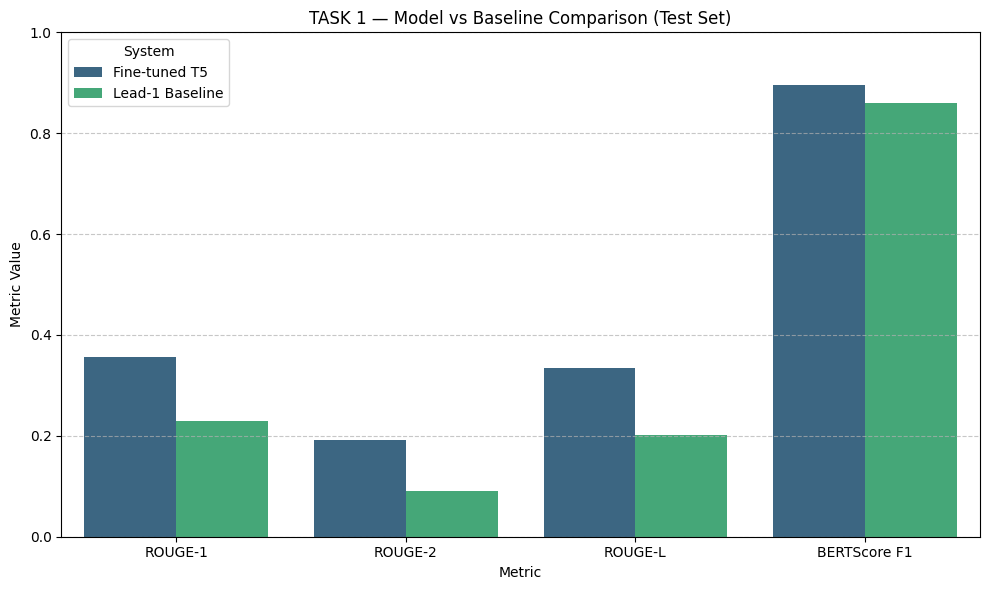

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from the previous cell's output (mTnNbReU9hmv)
metrics_data = {
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore F1'],
    'Fine-tuned T5': [0.3570, 0.1925, 0.3345, 0.8958],
    'Lead-1 Baseline': [0.2287, 0.0908, 0.2021, 0.8607]
}
df_metrics = pd.DataFrame(metrics_data)

# Melt the DataFrame to prepare for grouped bar plot
df_melted = df_metrics.melt(id_vars='Metric', var_name='System', value_name='Value')

# Create the bar plot
plt.figure(figsize=(10, 6))
import seaborn as sns
sns.barplot(x='Metric', y='Value', hue='System', data=df_melted, palette='viridis')

plt.title('TASK 1 — Model vs Baseline Comparison (Test Set)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Qualitative Examples
print("QUALITATIVE EXAMPLES (first 3 test samples)")
print("="*70)

for i in range(min(3, len(test_df))):
    row = test_df.iloc[i]
    print(f"\n Example {i+1} (File: {row['file_id']})")
    print('-'*30)
    print(f"CHQ Input (first 300 chars):\n  {row['chq'][:300]}{'...' if len(row['chq']) > 300 else ''}")
    print(f"Lead-1 Baseline:\n  {baseline_preds[i]}")
    print(f"Predicted Summary:\n  {pred_texts[i]}")
    print(f"Gold Summary:\n  {row['summary']}")
    print(f"BERTScore F1: {bs_results['f1'][i]:.4f}")


QUALITATIVE EXAMPLES (first 3 test samples)

 Example 1 (File: 16266.txt)
------------------------------
CHQ Input (first 300 chars):
  SUBJECT: new treatment for lipoma of forearm
MESSAGE: I have had two surgeries on my right forearm.  The last was 2 years ago.  The lipoma has returned.  Are there any new treatments or experimental procedures that might help me?
Lead-1 Baseline:
  SUBJECT: new treatment for lipoma of forearm
MESSAGE: I have had two surgeries on my right forearm.
Predicted Summary:
  What are the treatments for lipoma?
Gold Summary:
  What are the latest treatments for recurrent lipoma of the arm?
BERTScore F1: 0.9594

 Example 2 (File: 66.txt)
------------------------------
CHQ Input (first 300 chars):
  Beckwith-Wieddeman Syndrome. I would like to request further knowledge on this specific disorder.
Lead-1 Baseline:
  Beckwith-Wieddeman Syndrome.
Predicted Summary:
  What are the treatments and a treatment for Beckwith-Wieddeman, and are they for?
Gold Summary:
  Whe

In [ ]:
# Save Results CSV
results_df = pd.DataFrame({
    'file_id'        : test_df['file_id'].tolist(),
    'chq'            : test_df['chq'].tolist(),
    'gold_summary'   : ref_texts,
    'pred_summary'   : pred_texts,
    'lead1_baseline' : baseline_preds,
    'bertscore_f1'   : bs_results['f1'],
})
csv_path = os.path.join(OUTPUT_DIR, 'task1_test_results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")


Results saved to: /content/drive/MyDrive/medical_summarisation/task1_outputs/task1_test_results.csv


In [ ]:
# Load Saved Model (for inference later)
# Uncomment this block only when you want to load the saved model in a fresh session:
#
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SAVED_MODEL_PATH = '/content/drive/MyDrive/medical_summarisation/task1_outputs/flan_t5_task1_best'
tokenizer_t1 = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
model_t1     = AutoModelForSeq2SeqLM.from_pretrained(SAVED_MODEL_PATH)
model_t1.eval()

# Example: Test if the model is loaded properly with an example
chq = "SUBJECT: Ear pain MESSAGE: I have had ear pain for the past 3 days ..."
print(summarize_chq(chq, model_obj=model_t1, tok_obj=tokenizer_t1))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


What are the treatments for ear pain?


# MEDIQA 2021 — TASK 1: Model Comparison + Error Analysis

FLAN-T5-base  (load from Drive if saved, else train)

   vs

BioM-T5-base  (load from Drive if saved, else train)

   vs

Lead-1 Baseline (first sentence of CHQ)

Error Analysis:
   1. Hallucination  — key nouns in prediction not found in CHQ input
   2. Topic Drift    — BERTScore(pred, gold) < 0.85
   3. Under-compress — compression ratio > 0.6  (summary nearly as long as CHQ)
   4. Over-compress  — summary is <= 3 words
   5. Verbatim Copy  — prediction identical to Lead-1 baseline

In [ ]:
# Imports

import os
import re
import numpy as np
import pandas as pd
import torch
import nltk

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize

from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

In [ ]:
# Paths & Hyperparameters
MEQSUM_PATH  = (
    '/content/drive/MyDrive/medical_summarisation/'
    'MeQSum_ACL2019_BenAbacha_Demner-Fushman.xlsx'
)
OUTPUT_DIR   = '/content/drive/MyDrive/medical_summarisation/task1_outputs'
FLANT5_PATH  = os.path.join(OUTPUT_DIR, 'flan_t5_task1_best')
BIOMT5_PATH  = os.path.join(OUTPUT_DIR, 'scifive_task1_best')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FLANT5_HF    = 'google/flan-t5-base'
BIOMT5_HF    = 'razent/SciFive-base-Pubmed_Pmc'

MAX_INPUT_LEN    = 512
MAX_TARGET_LEN   = 64
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE  = 16
NUM_EPOCHS       = 5
LR               = 5e-5
N_TEST, N_VAL    = 100, 100   # same seed-42 split as first pipeline

# Error analysis thresholds
TOPIC_DRIFT_THRESHOLD     = 0.85   # BERTScore F1 below this → topic drift
UNDER_COMPRESS_THRESHOLD  = 0.60   # summary/chq word ratio above this → under-compressed
OVER_COMPRESS_MAX_WORDS   = 3      # summary with <= this many words → over-compressed


In [ ]:
# Load from the saved model path else train
def is_model_saved(path: str) -> bool:
    """
    Returns True if a valid HuggingFace model checkpoint exists at `path`.
    Checks for the presence of config.json as the minimum required file.
    """
    config_path = os.path.join(path, 'config.json')
    exists = os.path.isfile(config_path)
    if exists:
        print(f"Found saved model at: {path}")
    else:
        print(f"No saved model at: {path} -> will train from scratch")
    return exists


def load_or_train(
    hf_model_name: str,
    save_path: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    label: str,
) -> tuple:
    """
    Load a model+tokenizer from `save_path` if it exists.
    Otherwise fine-tune `hf_model_name` on `train_df`/`val_df` and save.

    Returns:
        (model, tokenizer)
    """
    print(f"\n[{label}] Checking for saved checkpoint …")

    if is_model_saved(save_path):
        print(f"[{label}] Loading from disk …")
        tok   = AutoTokenizer.from_pretrained(save_path)
        model = AutoModelForSeq2SeqLM.from_pretrained(save_path)
        model.eval()
        print(f"[{label}] Loaded successfully.")
        return model, tok

    # Not saved the train
    print(f"[{label}] Loading base model from HuggingFace: {hf_model_name} …")
    tok   = AutoTokenizer.from_pretrained(hf_model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(hf_model_name)
    print(f"[{label}] Parameters: {sum(p.numel() for p in model.parameters()):,}")

    tok_train_ds = make_tok_dataset(train_df, tok)
    tok_val_ds   = make_tok_dataset(val_df,   tok)
    collator     = DataCollatorForSeq2Seq(tokenizer=tok, model=model, padding=True)

    args = Seq2SeqTrainingArguments(
        output_dir                  = os.path.join(OUTPUT_DIR, f'{label.lower().replace(" ", "_")}_ckpts'),
        per_device_train_batch_size = TRAIN_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        num_train_epochs            = NUM_EPOCHS,
        learning_rate               = LR,
        warmup_steps                = 50,
        predict_with_generate       = True,
        generation_max_length       = MAX_TARGET_LEN,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'rougeL',
        greater_is_better           = True,
        logging_steps               = 20,
        save_total_limit            = 2,
        fp16                        = False,
        push_to_hub                 = False,
    )

    trainer = Seq2SeqTrainer(
        model            = model,
        args             = args,
        train_dataset    = tok_train_ds,
        eval_dataset     = tok_val_ds,
        processing_class = tok,
        data_collator    = collator,
        compute_metrics  = make_compute_metrics(tok),
    )

    print(f"[{label}] Fine-tuning …")
    trainer.train()
    trainer.save_model(save_path)
    tok.save_pretrained(save_path)
    print(f"[{label}] Saved to: {save_path}")

    model.eval()
    return model, tok

In [ ]:
#  Shared Helpers
PREFIX = "Summarize this health question into one concise question: "

def add_prefix(text: str) -> str:
    return PREFIX + text


def make_tok_dataset(split_df: pd.DataFrame, tokenizer) -> Dataset:
    def _tok(batch):
        inp = tokenizer(
            [add_prefix(q) for q in batch['chq']],
            max_length=MAX_INPUT_LEN,
            truncation=True,
            padding='max_length',
        )
        tgt = tokenizer(
            batch['summary'],
            max_length=MAX_TARGET_LEN,
            truncation=True,
            padding='max_length',
        )
        inp['labels'] = tgt['input_ids']
        return inp

    ds = Dataset.from_dict({
        'chq':     split_df['chq'].tolist(),
        'summary': split_df['summary'].tolist(),
    })
    return ds.map(_tok, batched=True, remove_columns=['chq', 'summary'])


def make_compute_metrics(tokenizer):
    rouge = evaluate.load('rouge')

    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        vocab_size = tokenizer.vocab_size
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        preds  = np.clip(preds,  0, vocab_size - 1)
        labels = np.clip(labels, 0, vocab_size - 1)
        decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        result = rouge.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            use_stemmer=True,
        )
        return {k: round(v, 4) for k, v in result.items()}

    return compute_metrics


def generate_summary(model, tokenizer, chq_text: str) -> str:
    inp = tokenizer(
        add_prefix(chq_text),
        return_tensors='pt',
        truncation=True,
        max_length=MAX_INPUT_LEN,
    )
    inp = {k: v.to(model.device) for k, v in inp.items()}
    with torch.no_grad():
        out = model.generate(
            **inp,
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def run_inference(model, tokenizer, split_df: pd.DataFrame) -> list:
    model.eval()
    return [generate_summary(model, tokenizer, row['chq'])
            for _, row in split_df.iterrows()]

In [ ]:
# Load MeQSum & Recreate Identical Split
print("Loading MeQSum")
df = pd.read_excel(MEQSUM_PATH, dtype=str)
df.columns = [c.strip() for c in df.columns]

file_col    = next(c for c in df.columns if 'FILE'  in c.upper())
chq_col     = next(c for c in df.columns if 'CHQ'   in c.upper())
summary_col = next(c for c in df.columns if 'SUMM'  in c.upper())

df = df[[file_col, chq_col, summary_col]].dropna(subset=[chq_col, summary_col])
df.columns = ['file_id', 'chq', 'summary']
df['chq']     = df['chq'].str.strip()
df['summary'] = df['summary'].str.strip()

# MUST use same seed=42 as the original pipeline
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = df.iloc[:N_TEST].reset_index(drop=True)
val_df   = df.iloc[N_TEST:N_TEST + N_VAL].reset_index(drop=True)
train_df = df.iloc[N_TEST + N_VAL:].reset_index(drop=True)

print(f"Split -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

Loading MeQSum
Split -> train: 800, val: 100, test: 100


In [ ]:
# Load or Train Both Models
model_flant5, tok_flant5 = load_or_train(
    FLANT5_HF, FLANT5_PATH, train_df, val_df, 'FLAN-T5'
)
model_biom, tok_biom = load_or_train(
    BIOMT5_HF, BIOMT5_PATH, train_df, val_df, 'SciFive'
)



[FLAN-T5] Checking for saved checkpoint …
Found saved model at: /content/drive/MyDrive/medical_summarisation/task1_outputs/flan_t5_task1_best
[FLAN-T5] Loading from disk …


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[FLAN-T5] Loaded successfully.

[SciFive] Checking for saved checkpoint …
Found saved model at: /content/drive/MyDrive/medical_summarisation/task1_outputs/scifive_task1_best
[SciFive] Loading from disk …


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

[SciFive] Loaded successfully.


In [ ]:
# Run Inference on Test Set
ref_texts = test_df['summary'].tolist()

print("\nGenerating FLAN-T5 predictions …")
preds_flant5 = run_inference(model_flant5, tok_flant5, test_df)

print("Generating BioM-T5 predictions …")
preds_biom = run_inference(model_biom, tok_biom, test_df)

print("Generating Lead-1 baseline predictions …")
preds_lead1 = [
    (sent_tokenize(row['chq'])[0] if sent_tokenize(row['chq']) else row['chq'])
    for _, row in test_df.iterrows()
]

print("Inference complete.")


Generating FLAN-T5 predictions …
Generating BioM-T5 predictions …
Generating Lead-1 baseline predictions …
Inference complete.


In [ ]:
# Compute ROUGE + BERTScore
# ──────────────────────────
rouge     = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')


def eval_system(preds: list, refs: list, label: str) -> dict:
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    b = bertscore.compute(predictions=preds, references=refs, lang='en')
    return {
        'system'      : label,
        'rouge1'      : round(r['rouge1'],             4),
        'rouge2'      : round(r['rouge2'],             4),
        'rougeL'      : round(r['rougeL'],             4),
        'bs_precision': round(np.mean(b['precision']), 4),
        'bs_recall'   : round(np.mean(b['recall']),    4),
        'bs_f1'       : round(np.mean(b['f1']),        4),
        '_bs_f1_list' : b['f1'],
    }


print("\nEvaluating systems")
res_lead1  = eval_system(preds_lead1,  ref_texts, 'Lead-1 Baseline')
res_flant5 = eval_system(preds_flant5, ref_texts, 'FLAN-T5-base (fine-tuned)')
res_biom   = eval_system(preds_biom,   ref_texts, 'BioM-T5-base (fine-tuned)')


Evaluating systems


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Print Metrics Table
# ───────────────────────
header  = f"{'System':<30} {'R-1':>7} {'R-2':>7} {'R-L':>7} {'BS-P':>7} {'BS-R':>7} {'BS-F1':>7}"
divider = "─" * len(header)

print("\n" + "=" * len(header))
print("TASK 1 — CHQ SUMMARIZATION — METRICS (test n=100)")
print("=" * len(header))
print(header)
print(divider)
for s in [res_lead1, res_flant5, res_biom]:
    print(
        f"{s['system']:<30}"
        f" {s['rouge1']:>7.4f}"
        f" {s['rouge2']:>7.4f}"
        f" {s['rougeL']:>7.4f}"
        f" {s['bs_precision']:>7.4f}"
        f" {s['bs_recall']:>7.4f}"
        f" {s['bs_f1']:>7.4f}"
    )



TASK 1 — CHQ SUMMARIZATION — METRICS (test n=100)
System                             R-1     R-2     R-L    BS-P    BS-R   BS-F1
──────────────────────────────────────────────────────────────────────────────
Lead-1 Baseline                 0.2296  0.0898  0.2028  0.8456  0.8777  0.8607
FLAN-T5-base (fine-tuned)       0.3549  0.1925  0.3340  0.8979  0.8944  0.8958
BioM-T5-base (fine-tuned)       0.5342  0.3748  0.5068  0.9424  0.9295  0.9356


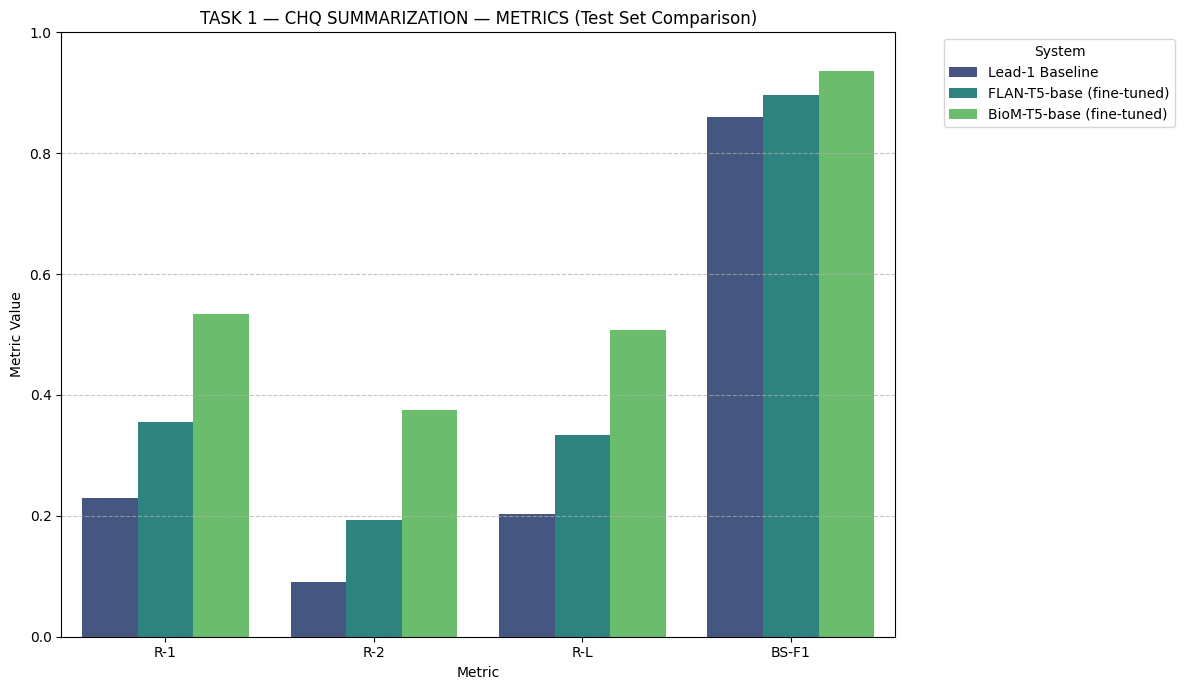

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from cell l9u9TAYqanfF's output
metrics_data = {
    'System': [
        'Lead-1 Baseline',
        'FLAN-T5-base (fine-tuned)',
        'BioM-T5-base (fine-tuned)'
    ],
    'R-1': [0.2296, 0.3549, 0.5342],
    'R-2': [0.0898, 0.1925, 0.3748],
    'R-L': [0.2028, 0.3340, 0.5068],
    'BS-P': [0.8456, 0.8979, 0.9424],
    'BS-R': [0.8777, 0.8944, 0.9295],
    'BS-F1': [0.8607, 0.8958, 0.9356]
}

df_metrics = pd.DataFrame(metrics_data)

# Melt the DataFrame to prepare for grouped bar plot
df_melted = df_metrics.melt(
    id_vars='System',
    var_name='Metric',
    value_name='Value'
)

# Filter out BS-P and BS-R to focus on R-1, R-2, R-L, BS-F1 for a cleaner plot
df_plot = df_melted[df_melted['Metric'].isin(['R-1', 'R-2', 'R-L', 'BS-F1'])]

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='System', data=df_plot, palette='viridis')

plt.title('TASK 1 — CHQ SUMMARIZATION — METRICS (Test Set Comparison)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# # Install when need and follow the below cell as well to install Cell A — use v0.5.4 throughout
# !pip install -q scispacy
# !pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

In [ ]:
# # Cell need to hard restart [mandatory]
# import os
# os.kill(os.getpid(), 9)

In [ ]:
# # Cell C — after restart, verify
# import spacy
# import scispacy
# nlp = spacy.load('en_core_sci_sm')
# print("spaCy version :", spacy.__version__)
# print("model loaded  :", nlp.meta['name'])

In [ ]:
import pandas as pd
import spacy

In [ ]:
# REPLACE WITH:
nlp_sci = spacy.load('en_core_sci_sm')   # add at top of cell with other imports

def get_medical_entities(text: str) -> set:
    """Extract biomedical named entities using scispaCy."""
    doc = nlp_sci(text[:5000])
    return {ent.text.lower() for ent in doc.ents if len(ent.text) > 2}


def classify_errors(
    preds: list,
    refs: list,
    chqs: list,
    lead1_preds: list,
    bs_f1_list: list,
) -> pd.DataFrame:
    """
    For each prediction, detect which error types are present.
    Returns a DataFrame with one row per example.
    """
    rows = []
    for i, (pred, ref, chq, lead1, bs) in enumerate(
        zip(preds, refs, chqs, lead1_preds, bs_f1_list)
    ):
        pred_words = pred.split()

        chq_words  = get_medical_entities(chq)
        pred_content = get_medical_entities(pred)

        # Hallucination: content words in prediction NOT present in CHQ
        hallucinated = pred_content - chq_words
        is_hallucination = len(hallucinated) > 0


        # Topic drift: BERTScore with gold below threshold
        is_topic_drift = bs < TOPIC_DRIFT_THRESHOLD

        # Under-compression: summary word count / chq word count > threshold
        chq_word_count  = len(chq.split())
        pred_word_count = len(pred_words)
        compression_ratio = pred_word_count / max(chq_word_count, 1)
        is_under_compressed = compression_ratio > UNDER_COMPRESS_THRESHOLD

        # Over-compression: prediction is very short
        is_over_compressed = pred_word_count <= OVER_COMPRESS_MAX_WORDS

        # Verbatim copy: identical to Lead-1
        is_verbatim_copy = pred.strip().lower() == lead1.strip().lower()

        rows.append({
            'idx'               : i,
            'chq'               : chq,
            'gold'              : ref,
            'pred'              : pred,
            'bs_f1'             : round(bs, 4),
            'hallucination'     : is_hallucination,
            'hallucinated_words': ', '.join(sorted(hallucinated)),
            'topic_drift'       : is_topic_drift,
            'under_compressed'  : is_under_compressed,
            'over_compressed'   : is_over_compressed,
            'verbatim_copy'     : is_verbatim_copy,
            'compression_ratio' : round(compression_ratio, 3),
            'pred_word_count'   : pred_word_count,
        })

    return pd.DataFrame(rows)


chqs = test_df['chq'].tolist()

print("\nRunning error analysis")
err_flant5 = classify_errors(
    preds_flant5, ref_texts, chqs, preds_lead1, res_flant5['_bs_f1_list']
)
err_biom = classify_errors(
    preds_biom, ref_texts, chqs, preds_lead1, res_biom['_bs_f1_list']
)
err_lead1 = classify_errors(
    preds_lead1, ref_texts, chqs, preds_lead1, res_lead1['_bs_f1_list']
)

error_cols = ['hallucination', 'topic_drift', 'under_compressed',
              'over_compressed', 'verbatim_copy']


def error_summary_table(err_dfs: list, labels: list) -> pd.DataFrame:
    rows = []
    for df_err, label in zip(err_dfs, labels):
        row = {'System': label}
        for col in error_cols:
            count = int(df_err[col].sum())
            pct   = round(count / len(df_err) * 100, 1)
            row[col] = f"{count} ({pct}%)"
        rows.append(row)
    return pd.DataFrame(rows)


err_table = error_summary_table(
    [err_lead1, err_flant5, err_biom],
    ['Lead-1 Baseline', 'FLAN-T5-base', 'BioM-T5-base'],
)

print("\n")
print("TASK 1 — ERROR ANALYSIS SUMMARY (counts and % of 100 test examples)")
print("=" * 90)
print(err_table.to_string(index=False))
print("=" * 90)
print("\nError definitions:")
print("  Hallucination    : content words in prediction not found in the CHQ input")
print("  Topic Drift      : BERTScore(pred, gold) < 0.85")
print("  Under-compressed : summary length > 60% of CHQ length")
print("  Over-compressed  : prediction is 3 words or fewer")
print("  Verbatim Copy    : prediction identical to Lead-1 (first sentence of CHQ)")


Running error analysis


TASK 1 — ERROR ANALYSIS SUMMARY (counts and % of 100 test examples)
         System hallucination topic_drift under_compressed over_compressed verbatim_copy
Lead-1 Baseline      3 (3.0%)  45 (45.0%)       29 (29.0%)      11 (11.0%)  100 (100.0%)
   FLAN-T5-base    98 (98.0%)    8 (8.0%)       10 (10.0%)        0 (0.0%)      0 (0.0%)
   BioM-T5-base    88 (88.0%)    2 (2.0%)         3 (3.0%)        0 (0.0%)      0 (0.0%)

Error definitions:
  Hallucination    : content words in prediction not found in the CHQ input
  Topic Drift      : BERTScore(pred, gold) < 0.85
  Under-compressed : summary length > 60% of CHQ length
  Over-compressed  : prediction is 3 words or fewer
  Verbatim Copy    : prediction identical to Lead-1 (first sentence of CHQ)


In [ ]:
# Worst Failure Examples Per Error Type
def worst_examples(err_df: pd.DataFrame, error_col: str, n: int = 2) -> pd.DataFrame:
    """Return the n worst examples for a given error type (lowest BERTScore F1)."""
    subset = err_df[err_df[error_col] == True].nsmallest(n, 'bs_f1')
    return subset[['idx', 'chq', 'gold', 'pred', 'bs_f1',
                   'hallucinated_words', 'compression_ratio']]


print("\n" + "=" * 80)
print("WORST FAILURE EXAMPLES PER ERROR TYPE")
print("=" * 80)

model_errors = [
    ('FLAN-T5-base', err_flant5),
    ('BioM-T5-base', err_biom),
]

for error_col in error_cols:
    print(f"\n{'─'*80}")
    print(f"ERROR TYPE: {error_col.upper().replace('_', ' ')}")
    print(f"{'─'*80}")
    for model_label, err_df in model_errors:
        worst = worst_examples(err_df, error_col, n=2)
        if worst.empty:
            print(f"  [{model_label}] No examples with this error type.")
            continue
        print(f"\n  [{model_label}] — {len(err_df[err_df[error_col]])} total cases")
        for _, row in worst.iterrows():
            chq_display = row['chq'][:250] + ('…' if len(row['chq']) > 250 else '')
            print(f"    Example #{int(row['idx'])+1}")
            print(f"    CHQ  : {chq_display}")
            print(f"    Gold : {row['gold']}")
            print(f"    Pred : {row['pred']}")
            print(f"    BS-F1: {row['bs_f1']:.4f}"
                  + (f"  | Hallucinated: {row['hallucinated_words']}"
                     if row['hallucinated_words'] else '')
                  + (f"  | Compression: {row['compression_ratio']:.2f}"
                     if error_col in ('under_compressed', 'over_compressed') else ''))
            print()


#  Qualitative Examples (3 samples, all three systems)
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_INDICES = [0, 1, 2]

print("\n")
print("QUALITATIVE EXAMPLES — all three systems side by side")
print("=" * 70)

for idx in SAMPLE_INDICES:
    row = test_df.iloc[idx]
    chq_display = row['chq'][:350] + ('…' if len(row['chq']) > 350 else '')
    print(f"\n{'─'*70}")
    print(f"Example {idx+1}  |  File: {row['file_id']}")
    print(f"{'─'*70}")
    print(f"CHQ Input:\n  {chq_display}")
    print(f"\nGold Summary:\n  {ref_texts[idx]}")
    print(f"\nLead-1 Baseline:\n  {preds_lead1[idx]}")
    print(f"  BS-F1: {res_lead1['_bs_f1_list'][idx]:.4f}")
    print(f"\nFLAN-T5-base:\n  {preds_flant5[idx]}")
    print(f"  BS-F1: {res_flant5['_bs_f1_list'][idx]:.4f}")
    print(f"\nBioM-T5-base:\n  {preds_biom[idx]}")
    print(f"  BS-F1: {res_biom['_bs_f1_list'][idx]:.4f}")

print(f"\n{'─'*70}")


WORST FAILURE EXAMPLES PER ERROR TYPE

────────────────────────────────────────────────────────────────────────────────
ERROR TYPE: HALLUCINATION
────────────────────────────────────────────────────────────────────────────────

  [FLAN-T5-base] — 98 total cases
    Example #28
    CHQ  : MESSAGE: I have to start applying ciclopirox to infected toes. I know u cannot use nail polish bit can I put a band aid on once the medication has dried?
    Gold : Can i cover ciclopirox with bandaids?
    Pred : What are the treatments and for a ioosis?
    BS-F1: 0.8205  | Hallucinated: ioosis, treatments

    Example #29
    CHQ  : SUBJECT: cosmetic leg shortening surgery
MESSAGE: Hi,  I am a tall girl(5'8"), who wants to undergo leg shortening sugery of 2 inches for cosmetic purpose. It would be good if I can get more information about it. I would like to know the cost of this…
    Gold : Where can I find information on leg shortening surgery, including risks, cost, and recovery time?
    Pred : 

In [ ]:
# Save All Results in CSV
results_df = pd.DataFrame({
    'file_id'          : test_df['file_id'].tolist(),
    'chq'              : chqs,
    'gold_summary'     : ref_texts,
    'lead1_pred'       : preds_lead1,
    'flant5_pred'      : preds_flant5,
    'biom_pred'        : preds_biom,
    'lead1_bs_f1'      : res_lead1['_bs_f1_list'],
    'flant5_bs_f1'     : res_flant5['_bs_f1_list'],
    'biom_bs_f1'       : res_biom['_bs_f1_list'],
})
results_df.to_csv(os.path.join(OUTPUT_DIR, 'task1_comparison_results.csv'), index=False)

# Aggregate metrics CSV
metrics_df = pd.DataFrame([
    {k: v for k, v in s.items() if not k.startswith('_')}
    for s in [res_lead1, res_flant5, res_biom]
])
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'task1_metrics_summary.csv'), index=False)

# Error analysis CSVs
err_flant5.to_csv(os.path.join(OUTPUT_DIR, 'task1_errors_flant5.csv'),  index=False)
err_biom.to_csv(  os.path.join(OUTPUT_DIR, 'task1_errors_biom.csv'),    index=False)
err_lead1.to_csv( os.path.join(OUTPUT_DIR, 'task1_errors_lead1.csv'),   index=False)

# Error summary table CSV
err_table.to_csv(os.path.join(OUTPUT_DIR, 'task1_error_summary.csv'), index=False)

print("\nAll results saved to:", OUTPUT_DIR)


All results saved to: /content/drive/MyDrive/medical_summarisation/task1_outputs


# TASK 1 — Val and Test Set Evaluation
- 1.1: Evaluate on official MEDIQA 2021 Val + Test sets
- 1.2: Add FLAN-T5 zero-shot baseline (no fine-tuning)


In [ ]:
# Path and config
MEDIQA_VAL_PATH  = (
    '/content/drive/MyDrive/medical_summarisation/'
    'MEDIQA2021-Task1-QuestionSummarization-ValidationSet.xlsx'
)

MEDIQA_TEST_PATH = (
    '/content/drive/MyDrive/medical_summarisation/'
    'MEDIQA2021-Task1-TestSet-ReferenceSummaries.xlsx'
)

OUTPUT_DIR   = '/content/drive/MyDrive/medical_summarisation/task1_outputs'
FLANT5_PATH  = '/content/drive/MyDrive/medical_summarisation/task1_outputs/flan_t5_task1_best'
SCIFIVE_PATH = '/content/drive/MyDrive/medical_summarisation/task1_outputs/scifive_task1_best'

FLANT5_HF    = 'google/flan-t5-base'

MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 64
PREFIX = "Summarize this health question into one concise question: "

In [ ]:
# !pip install -q transformers datasets evaluate bert_score rouge_score openpyxl nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import nltk

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

rouge     = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

In [ ]:
# Load Official MEDIQA Val & Test Sets
# ─────────────────────────────────────
def load_mediqa_split(path: str, label: str) -> pd.DataFrame:
    """
    Load an official MEDIQA Task 1 Excel file.
    Handles both:
      Val  (5 cols): q_id, NLM Question, Summary, Question Focus, Question Type
      Test (3 cols): q_id, NLM Question, Summary
    Returns a clean DataFrame with columns: q_id, chq, summary
    """
    df = pd.read_excel(path, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    print(f"\n[{label}] Columns found: {list(df.columns)}")
    print(f"[{label}] Raw rows: {len(df)}")

    # Map column names flexibly
    q_id_col    = next(c for c in df.columns if 'Q_ID'    in c.upper() or c.upper() == 'Q_ID')
    chq_col     = next(c for c in df.columns if 'NLM'     in c.upper() or 'QUESTION' in c.upper())
    summary_col = next(c for c in df.columns if 'SUMM'    in c.upper())

    df = df[[q_id_col, chq_col, summary_col]].copy()
    df.columns = ['q_id', 'chq', 'summary']

    # Drop rows with missing CHQ or Summary
    df = df.dropna(subset=['chq', 'summary']).reset_index(drop=True)
    df['chq']     = df['chq'].str.strip()
    df['summary'] = df['summary'].str.strip()
    df = df[df['chq'] != ''].reset_index(drop=True)
    df = df[df['summary'] != ''].reset_index(drop=True)

    print(f"[{label}] Clean rows: {len(df)}")
    print(f"[{label}] Example CHQ    : {df['chq'].iloc[0][:120]}")
    print(f"[{label}] Example Summary: {df['summary'].iloc[0]}")
    return df


val_df_official  = load_mediqa_split(MEDIQA_VAL_PATH,  'MEDIQA-Val')
test_df_official = load_mediqa_split(MEDIQA_TEST_PATH, 'MEDIQA-Test')



[MEDIQA-Val] Columns found: ['q_id', 'NLM Question', 'Summary', 'Question Focus', 'Question Type']
[MEDIQA-Val] Raw rows: 50
[MEDIQA-Val] Clean rows: 50
[MEDIQA-Val] Example CHQ    : I'm 53 years old. I have got  meniscus tear after a twist. My MRI reports  that I  have got: 1. Bucket handle tear invol
[MEDIQA-Val] Example Summary: Should I leave a meniscus tear untreated if it does not cause problems?

[MEDIQA-Test] Columns found: ['q_id', 'NLM Question', 'Summary']
[MEDIQA-Test] Raw rows: 100
[MEDIQA-Test] Clean rows: 100
[MEDIQA-Test] Example CHQ    : 23 surgeries and counting......lower lip birthmark, have tried all options out the there and guess what still have it, c
[MEDIQA-Test] Example Summary: How can i get rid of a lower lip birthmark permanently?


In [ ]:
# Load Saved Fine-tuned Models
def load_saved_model(path: str, label: str):
    """Load a fine-tuned model + tokenizer from disk."""
    config_file = os.path.join(path, 'config.json')
    if not os.path.isfile(config_file):
        raise FileNotFoundError(
            f"[{label}] No config.json found at {path}. "
            "Make sure the model was saved correctly."
        )
    print(f"[{label}] Loading from {path} …")
    tok   = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSeq2SeqLM.from_pretrained(path)
    model.eval()
    print(f"[{label}] Loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")
    return model, tok


model_flant5, tok_flant5 = load_saved_model(FLANT5_PATH,  'FLAN-T5 fine-tuned')
model_scifive, tok_scifive = load_saved_model(SCIFIVE_PATH, 'SciFive fine-tuned')

[FLAN-T5 fine-tuned] Loading from /content/drive/MyDrive/medical_summarisation/task1_outputs/flan_t5_task1_best …


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[FLAN-T5 fine-tuned] Loaded. Parameters: 247,577,856
[SciFive fine-tuned] Loading from /content/drive/MyDrive/medical_summarisation/task1_outputs/scifive_task1_best …


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

[SciFive fine-tuned] Loaded. Parameters: 222,903,552


In [ ]:
# Gap 2: Load FLAN-T5 Zero-Shot (base, no fine-tuning)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n[FLAN-T5 zero-shot] Loading base model from HuggingFace: {FLANT5_HF}")
tok_zeroshot   = AutoTokenizer.from_pretrained(FLANT5_HF)
model_zeroshot = AutoModelForSeq2SeqLM.from_pretrained(FLANT5_HF)
model_zeroshot.eval()
print("[FLAN-T5 zero-shot] Loaded.")


# Inference Helpers
# ──────────────────
def generate_summary(model, tokenizer, chq_text: str) -> str:
    inp = tokenizer(
        PREFIX + chq_text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_INPUT_LEN,
    )
    inp = {k: v.to(model.device) for k, v in inp.items()}
    with torch.no_grad():
        out = model.generate(
            **inp,
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def run_inference(model, tokenizer, df: pd.DataFrame) -> list:
    model.eval()
    preds = []
    for _, row in df.iterrows():
        preds.append(generate_summary(model, tokenizer, row['chq']))
    return preds


def lead_1(chq_text: str) -> str:
    sents = sent_tokenize(chq_text)
    return sents[0] if sents else chq_text


def eval_system(preds: list, refs: list, label: str) -> dict:
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    b = bertscore.compute(predictions=preds, references=refs, lang='en')
    return {
        'system'      : label,
        'rouge1'      : round(r['rouge1'],             4),
        'rouge2'      : round(r['rouge2'],             4),
        'rougeL'      : round(r['rougeL'],             4),
        'bs_precision': round(np.mean(b['precision']), 4),
        'bs_recall'   : round(np.mean(b['recall']),    4),
        'bs_f1'       : round(np.mean(b['f1']),        4),
        '_bs_f1_list' : b['f1'],
        '_preds'      : preds,
    }


def print_metrics_table(results: list, title: str, n: int):
    header  = f"{'System':<30} {'R-1':>7} {'R-2':>7} {'R-L':>7} {'BS-P':>7} {'BS-R':>7} {'BS-F1':>7}"
    divider = "─" * len(header)
    print(f"\n{'=' * len(header)}")
    print(f"{title} (n={n})")
    print(f"{'=' * len(header)}")
    print(header)
    print(divider)
    for s in results:
        print(
            f"{s['system']:<30}"
            f" {s['rouge1']:>7.4f}"
            f" {s['rouge2']:>7.4f}"
            f" {s['rougeL']:>7.4f}"
            f" {s['bs_precision']:>7.4f}"
            f" {s['bs_recall']:>7.4f}"
            f" {s['bs_f1']:>7.4f}"
        )
    print("=" * len(header))


[FLAN-T5 zero-shot] Loading base model from HuggingFace: google/flan-t5-base


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

[FLAN-T5 zero-shot] Loaded.


In [ ]:
# Running Inference on Val Set
# ───────────────────────────────────
val_refs = val_df_official['summary'].tolist()

print("\nRunning inference on MEDIQA Val set")
val_lead1    = [lead_1(row['chq']) for _, row in val_df_official.iterrows()]
val_zeroshot = run_inference(model_zeroshot, tok_zeroshot, val_df_official)
val_flant5   = run_inference(model_flant5,   tok_flant5,   val_df_official)
val_scifive  = run_inference(model_scifive,  tok_scifive,  val_df_official)

print("Evaluating Val set")
val_results = [
    eval_system(val_lead1,    val_refs, 'Lead-1 Baseline'),
    eval_system(val_zeroshot, val_refs, 'FLAN-T5-base (zero-shot)'),
    eval_system(val_flant5,   val_refs, 'FLAN-T5-base (fine-tuned)'),
    eval_system(val_scifive,  val_refs, 'SciFive-base (fine-tuned)'),
]

print_metrics_table(
    val_results,
    'TASK 1 — OFFICIAL MEDIQA VAL SET',
    len(val_df_official),
)


# Running Inference on Test Set
test_refs = test_df_official['summary'].tolist()

print("\nRunning inference on MEDIQA Test set")
test_lead1    = [lead_1(row['chq']) for _, row in test_df_official.iterrows()]
test_zeroshot = run_inference(model_zeroshot, tok_zeroshot, test_df_official)
test_flant5   = run_inference(model_flant5,   tok_flant5,   test_df_official)
test_scifive  = run_inference(model_scifive,  tok_scifive,  test_df_official)

print("Evaluating Test set")
test_results = [
    eval_system(test_lead1,    test_refs, 'Lead-1 Baseline'),
    eval_system(test_zeroshot, test_refs, 'FLAN-T5-base (zero-shot)'),
    eval_system(test_flant5,   test_refs, 'FLAN-T5-base (fine-tuned)'),
    eval_system(test_scifive,  test_refs, 'SciFive-base-PubMed (fine-tuned)'),
]

print_metrics_table(
    test_results,
    'TASK 1 — OFFICIAL MEDIQA TEST SET',
    len(test_df_official),
)


Running inference on MEDIQA Val set
Evaluating Val set


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TASK 1 — OFFICIAL MEDIQA VAL SET (n=50)
System                             R-1     R-2     R-L    BS-P    BS-R   BS-F1
──────────────────────────────────────────────────────────────────────────────
Lead-1 Baseline                 0.2178  0.0917  0.1824  0.8723  0.8763  0.8738
FLAN-T5-base (zero-shot)        0.2265  0.1010  0.2160  0.8911  0.8784  0.8843
FLAN-T5-base (fine-tuned)       0.2223  0.0565  0.2017  0.8889  0.8775  0.8828
SciFive-base (fine-tuned)       0.3415  0.1695  0.3368  0.9278  0.9100  0.9187

Running inference on MEDIQA Test set
Evaluating Test set

TASK 1 — OFFICIAL MEDIQA TEST SET (n=100)
System                             R-1     R-2     R-L    BS-P    BS-R   BS-F1
──────────────────────────────────────────────────────────────────────────────
Lead-1 Baseline                 0.2090  0.0792  0.1769  0.8642  0.8743  0.8687
FLAN-T5-base (zero-shot)        0.2265  0.0827  0.2043  0.8860  0.8831  0.8842
FLAN-T5-base (fine-tuned)       0.2023  0.0443  0.1851  0.8794  0.87

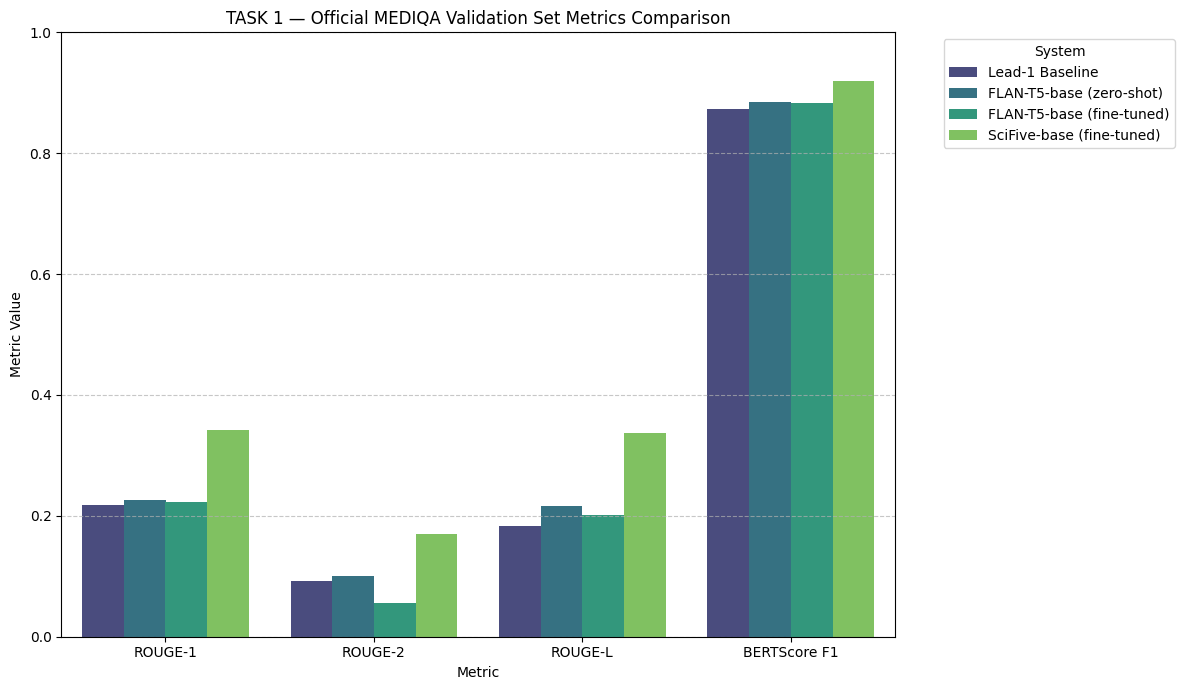

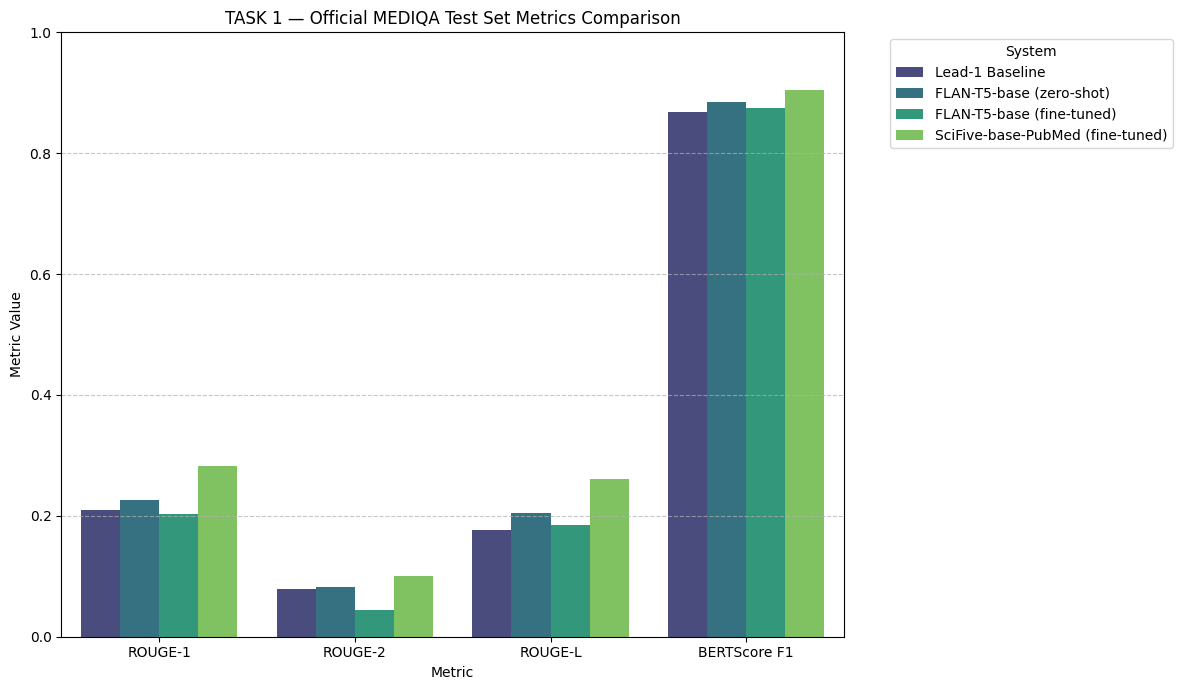

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_data = []

# Add validation set results
for result in val_results:
    if 'rouge1' in result:
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-1', 'Value': result['rouge1'], 'Set': 'MEDIQA Val'})
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-2', 'Value': result['rouge2'], 'Set': 'MEDIQA Val'})
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-L', 'Value': result['rougeL'], 'Set': 'MEDIQA Val'})
        plot_data.append({'System': result['system'], 'Metric': 'BERTScore F1', 'Value': result['bs_f1'], 'Set': 'MEDIQA Val'})

# Add test set results
for result in test_results:
    if 'rouge1' in result:
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-1', 'Value': result['rouge1'], 'Set': 'MEDIQA Test'})
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-2', 'Value': result['rouge2'], 'Set': 'MEDIQA Test'})
        plot_data.append({'System': result['system'], 'Metric': 'ROUGE-L', 'Value': result['rougeL'], 'Set': 'MEDIQA Test'})
        plot_data.append({'System': result['system'], 'Metric': 'BERTScore F1', 'Value': result['bs_f1'], 'Set': 'MEDIQA Test'})

df_plot = pd.DataFrame(plot_data)

# Filter data for validation set
df_val_plot = df_plot[df_plot['Set'] == 'MEDIQA Val']

# Create the grouped bar plot for Validation Set
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='System', data=df_val_plot, palette='viridis')
plt.title('TASK 1 — Official MEDIQA Validation Set Metrics Comparison')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Filter data for test set
df_test_plot = df_plot[df_plot['Set'] == 'MEDIQA Test']

# Create the grouped bar plot for Test Set
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='System', data=df_test_plot, palette='viridis')
plt.title('TASK 1 — Official MEDIQA Test Set Metrics Comparison')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Qualitative Examples on Official Test Set (3 samples)
# ────────────────────────────────────────────────────────────
print("\n")
print("QUALITATIVE EXAMPLES — Official MEDIQA Test Set")
print("=" * 65)

for idx in range(min(3, len(test_df_official))):
    row = test_df_official.iloc[idx]
    chq_display = row['chq'][:350] + ('…' if len(row['chq']) > 350 else '')
    bs_zs  = test_results[1]['_bs_f1_list'][idx]
    bs_ft  = test_results[2]['_bs_f1_list'][idx]
    bs_sci = test_results[3]['_bs_f1_list'][idx]

    print(f"\n{'─'*75}")
    print(f"Example {idx+1}  |  q_id: {row['q_id']}")
    print(f"{'─'*75}")
    print(f"CHQ Input:\n  {chq_display}")
    print(f"\nGold Summary:\n  {test_refs[idx]}")
    print(f"\nLead-1 Baseline:\n  {test_lead1[idx]}")
    print(f"\nFLAN-T5 zero-shot:\n  {test_zeroshot[idx]}"
          f"\n  BS-F1: {bs_zs:.4f}")
    print(f"\nFLAN-T5 fine-tuned:\n  {test_flant5[idx]}"
          f"\n  BS-F1: {bs_ft:.4f}")
    print(f"\nSciFive fine-tuned:\n  {test_scifive[idx]}"
          f"\n  BS-F1: {bs_sci:.4f}")

print(f"\n{'─'*75}")




QUALITATIVE EXAMPLES — Official MEDIQA Test Set

───────────────────────────────────────────────────────────────────────────
Example 1  |  q_id: 96
───────────────────────────────────────────────────────────────────────────
CHQ Input:
  23 surgeries and counting......lower lip birthmark, have tried all options out the there and guess what still have it, continues to grow back.....any suggestions? Is there a cure coming in the next few years hopefully?

Gold Summary:
  How can i get rid of a lower lip birthmark permanently?

Lead-1 Baseline:
  23 surgeries and counting......lower lip birthmark, have tried all options out the there and guess what still have it, continues to grow back.....any suggestions?

FLAN-T5 zero-shot:
  Is there a cure for lower lip birthmark?
  BS-F1: 0.9366

FLAN-T5 fine-tuned:
  What are the treatments and for a skin if it is for a lining and is there a treatment for it?
  BS-F1: 0.8535

SciFive fine-tuned:
  What are the treatments for lower lip birthmark?
  

In [ ]:
# Save All Results
# ──────────────────────
# Val set predictions
val_out = pd.DataFrame({
    'q_id'            : val_df_official['q_id'].tolist(),
    'chq'             : val_df_official['chq'].tolist(),
    'gold_summary'    : val_refs,
    'lead1_pred'      : val_lead1,
    'zeroshot_pred'   : val_zeroshot,
    'flant5_pred'     : val_flant5,
    'scifive_pred'    : val_scifive,
    'zeroshot_bs_f1'  : val_results[1]['_bs_f1_list'],
    'flant5_bs_f1'    : val_results[2]['_bs_f1_list'],
    'scifive_bs_f1'   : val_results[3]['_bs_f1_list'],
})
val_out.to_csv(
    os.path.join(OUTPUT_DIR, 'task1_mediqa_val_results.csv'), index=False
)

# Test set predictions
test_out = pd.DataFrame({
    'q_id'            : test_df_official['q_id'].tolist(),
    'chq'             : test_df_official['chq'].tolist(),
    'gold_summary'    : test_refs,
    'lead1_pred'      : test_lead1,
    'zeroshot_pred'   : test_zeroshot,
    'flant5_pred'     : test_flant5,
    'scifive_pred'    : test_scifive,
    'zeroshot_bs_f1'  : test_results[1]['_bs_f1_list'],
    'flant5_bs_f1'    : test_results[2]['_bs_f1_list'],
    'scifive_bs_f1'   : test_results[3]['_bs_f1_list'],
})
test_out.to_csv(
    os.path.join(OUTPUT_DIR, 'task1_mediqa_test_results.csv'), index=False
)

# Aggregate metrics — both splits side by side
def metrics_row(res: dict, split: str) -> dict:
    return {
        'split'       : split,
        'system'      : res['system'],
        'rouge1'      : res['rouge1'],
        'rouge2'      : res['rouge2'],
        'rougeL'      : res['rougeL'],
        'bs_precision': res['bs_precision'],
        'bs_recall'   : res['bs_recall'],
        'bs_f1'       : res['bs_f1'],
    }

all_metrics = (
    [metrics_row(r, 'val')  for r in val_results] +
    [metrics_row(r, 'test') for r in test_results]
)
pd.DataFrame(all_metrics).to_csv(
    os.path.join(OUTPUT_DIR, 'task1_official_metrics_summary.csv'), index=False
)

print("\nSaved:")
print(f"  {OUTPUT_DIR}/task1_mediqa_val_results.csv")
print(f"  {OUTPUT_DIR}/task1_mediqa_test_results.csv")
print(f"  {OUTPUT_DIR}/task1_official_metrics_summary.csv")


Saved:
  /content/drive/MyDrive/medical_summarisation/task1_outputs/task1_mediqa_val_results.csv
  /content/drive/MyDrive/medical_summarisation/task1_outputs/task1_mediqa_test_results.csv
  /content/drive/MyDrive/medical_summarisation/task1_outputs/task1_official_metrics_summary.csv


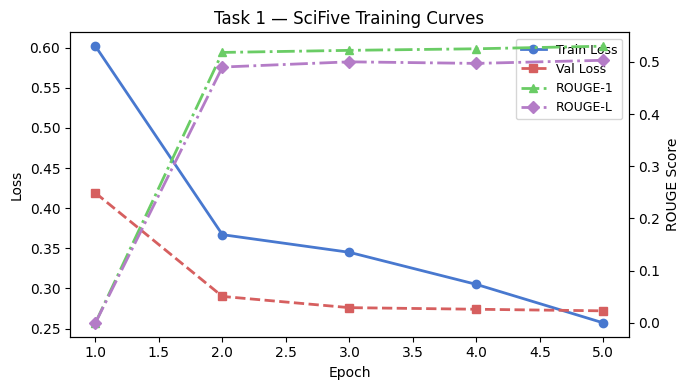

In [ ]:
import matplotlib.pyplot as plt

epochs     = [1, 2, 3, 4, 5]
train_loss = [0.602, 0.367, 0.345, 0.305, 0.257]
val_loss   = [0.419, 0.290, 0.276, 0.274, 0.272]
rouge1     = [0.000, 0.518, 0.522, 0.525, 0.530]
rougel     = [0.000, 0.490, 0.500, 0.497, 0.503]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, train_loss, 'o-', color='#4878CF', lw=2, label='Train Loss')
ax1.plot(epochs, val_loss,   's--', color='#D65F5F', lw=2, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2 = ax1.twinx()
ax2.plot(epochs, rouge1, '^-.', color='#6ACC65', lw=2, label='ROUGE-1')
ax2.plot(epochs, rougel, 'D-.', color='#B47CC7', lw=2, label='ROUGE-L')
ax2.set_ylabel('ROUGE Score')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.set_title('Task 1 — SciFive Training Curves')
plt.tight_layout()
plt.savefig('task1_training_curves.png', dpi=150)

--------------
---------------

# TASK 2: Multi-Answer Summarization
 ### Data Preparation
 ### Merge PDF the two dataset together

```
 3-Stage Pipeline:
  Stage 1 → Longformer extractive sentence classifier (per answer)
  Stage 2 → scispaCy NER-guided re-ranking across answers
  Stage 3 → FLAN-T5 abstractive fusion → final combined summary

Data   : /content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json
Outputs: /content/drive/MyDrive/medical_summarisation/task2_outputs/
Split  : 125 train / 16 val / 15 test  (seed=42)

```

In [ ]:
import json

# Load both files
with open("/content/drive/MyDrive/medical_summarisation/task2_data/page2answer_multi_extractive_summ.json", "r") as f:
    extractive_data = json.load(f)

with open("/content/drive/MyDrive/medical_summarisation/task2_data/page2answer_multi_abstractive_summ.json", "r") as f:
    abstractive_data = json.load(f)

merged_data = {}

# Merge based on keys
for key in extractive_data:
    if key in abstractive_data:
        merged_data[key] = {
            "question": extractive_data[key].get("question"),
            "articles": extractive_data[key].get("articles"),
            "extractive_summary": extractive_data[key].get("summary"),
            "abstractive_summary": abstractive_data[key].get("summary")
        }
    else:
        # handle missing keys if needed
        merged_data[key] = extractive_data[key]

# Optional: include keys only present in abstractive file
for key in abstractive_data:
    if key not in merged_data:
        merged_data[key] = {
            "question": abstractive_data[key].get("question"),
            "articles": abstractive_data[key].get("articles"),
            "abstractive_summary": abstractive_data[key].get("summary")
        }

# Save output
with open("/content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json", "w") as f:
    json.dump(merged_data, f, indent=4)

print("Merging complete. Output saved to merged_output.json")

Merging complete. Output saved to merged_output.json


In [ ]:
import json

# Display the first 3 items of the merged_data for a sample view
print(json.dumps(dict(list(merged_data.items())[:2]), indent=2))

{
  "1": {
    "question": "abetalipoproteimemia hi, I would like to know if there is any support for those suffering with abetalipoproteinemia? I am not diagnosed but have had many test that indicate I am suffering with this, keen to learn how to get it diagnosed and how to manage, many thanks",
    "articles": {
      "1_Answer1": [
        " Abetalipoproteinemia abetalipoproteinaemia abetalipoproteinemia neuropathy ABL acanthocytosis apolipoprotein B deficiency Bassen-Kornzweig disease Bassen-Kornzweig syndrome betalipoprotein deficiency disease congenital betalipoprotein deficiency syndrome microsomal triglyceride transfer protein deficiency disease MTP deficiency Description Abetalipoproteinemia is an inherited disorder that impairs the normal absorption of fats and certain vitamins from the diet. Many of the signs and symptoms of abetalipoproteinemia result from a severe shortage (deficiency) of fat-soluble vitamins (vitamins A, E, and K). The signs and symptoms of this condition

In [ ]:
# Install packages (run once)
# !pip install -q torch --index-url https://download.pytorch.org/whl/cu121
# !pip install -q transformers datasets evaluate bert_score rouge_score nltk
# !pip install -q scispacy
# !pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.3/en_core_sci_sm-0.5.3.tar.gz

# Import scispacy

In [ ]:
# Install when need and follow the below cell as well to install Cell A — use v0.5.4 throughout
!pip install -q scispacy
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 233.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 44.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", bu

In [ ]:
# Cell need to hard restart [mandatory]
import os
os.kill(os.getpid(), 9)

In [ ]:
# Cell C — after restart, verify
import spacy
import scispacy
nlp = spacy.load('en_core_sci_sm')
print("spaCy version :", spacy.__version__)
print("model loaded  :", nlp.meta['name'])

# MEDIQA 2021 — TASK 2: Multi-Answer Summarization

```
# 3-Stage Pipeline:
#   Stage 1 → Longformer extractive sentence classifier (per answer)
#   Stage 2 → scispaCy NER-guided re-ranking across answers
#   Stage 3 → FLAN-T5 abstractive fusion → final combined summary
#
# Data   : /content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json
# Outputs: /content/drive/MyDrive/medical_summarisation/task2_outputs/
# Split  : 109 train / 24 val / 23 test  (seed=42, 70/15/15)
#
# JSON structure:
#   data[qid] = {
#     "question"            : str,
#     "articles"            : { answer_id: [article_text, rating_str], ... },
#     "extractive_summary"  : str,   ← gold multi-answer extractive
#     "abstractive_summary" : str,   ← gold multi-answer abstractive
#   }
#
# Rating scale: "1-Bad" < "2-Fair" < "3-Incomplete" < "4-Excellent"
# Rating is used as a quality weight during Stage 1 scoring.
```

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import nltk
from difflib import SequenceMatcher
from typing import List, Dict, Tuple
from tqdm.auto import tqdm

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import spacy
import scispacy

from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Trainer, TrainingArguments,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorWithPadding,
    DataCollatorForSeq2Seq,
)

print("All imports successful.")

All imports successful.


In [ ]:
DATA_PATH   = '/content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json'
OUTPUT_DIR  = '/content/drive/MyDrive/medical_summarisation/task2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LONGFORMER_HF   = 'allenai/longformer-base-4096'
FLANT5_HF       = 'google/flan-t5-base'
LONGFORMER_SAVE = os.path.join(OUTPUT_DIR, 'longformer_extractive')
FLANT5_SAVE     = os.path.join(OUTPUT_DIR, 'flan_t5_abstractive')


N_TEST = 23
N_VAL  = 24
SEED   = 42

# Hyperparameters
MAX_SENT_LEN     = 512    # Longformer per-sentence max tokens
MAX_INPUT_LEN    = 1024   # FLAN-T5 input max tokens
MAX_TARGET_LEN   = 200    # FLAN-T5 output max tokens
TOP_K_PER_ANSWER = 3      # top sentences to keep per answer in Stage 1
NER_BOOST        = 0.15   # score boost for sentences with medical entities
CONSENSUS_BOOST  = 0.10   # extra boost if entity appears in ≥2 answers
SIM_THRESHOLD    = 0.6    # similarity threshold for extractive label generation

# Rating -> numeric quality weight (used in Stage 1 scoring)
RATING_WEIGHTS = {
    '1-bad'        : 0.5,
    '2-fair'       : 0.75,
    '3-incomplete' : 0.9,
    '4-excellent'  : 1.0,
}

print("Config set.")
print(f"  Longformer -> {LONGFORMER_SAVE}")
print(f"  FLAN-T5   -> {FLANT5_SAVE}")


Config set.
  Longformer -> /content/drive/MyDrive/medical_summarisation/task2_outputs/longformer_extractive
  FLAN-T5   -> /content/drive/MyDrive/medical_summarisation/task2_outputs/flan_t5_abstractive


In [ ]:
# Load & Inspect Data
print(f"\nLoading: {DATA_PATH}")
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Normalise to list; each entry keeps its question_id as '_id'
entries = []
for qid, obj in raw_data.items():
    obj['_id'] = str(qid)
    entries.append(obj)

print(f"Total questions: {len(entries)}")

# Quick structure check on first entry
s = entries[0]
print(f"Keys           : {list(s.keys())}")
print(f"Question       : {s.get('question','')[:100]}")
articles  = s.get('articles', {})
first_aid = list(articles.keys())[0]
print(f"Articles keys  : {list(articles.keys())[:3]} …")
print(f"First answer   : text={str(articles[first_aid][0])[:60]}…  rating={articles[first_aid][1]}")
print(f"extractive_summary  : {str(s.get('extractive_summary',''))[:80]}")
print(f"abstractive_summary : {str(s.get('abstractive_summary',''))[:80]}")


#  Split into Train / Val / Test & Save
random.seed(SEED)
shuffled = entries.copy()
random.shuffle(shuffled)

test_entries  = shuffled[:N_TEST]
val_entries   = shuffled[N_TEST:N_TEST + N_VAL]
train_entries = shuffled[N_TEST + N_VAL:]

print(f"Split -> train: {len(train_entries)}, val: {len(val_entries)}, test: {len(test_entries)}")

def save_split(split_entries: list, name: str):
    path = os.path.join(OUTPUT_DIR, f'task2_{name}.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump({e['_id']: e for e in split_entries}, f, indent=2)
    print(f"  Saved -> {path}")

save_split(train_entries, 'train')
save_split(val_entries,   'val')
save_split(test_entries,  'test')


# Helper Functions
def parse_rating(rating_str: str) -> float:
    """Convert rating string to a numeric weight in [0.5, 1.0]."""
    key = str(rating_str).strip().lower()
    if key in RATING_WEIGHTS:
        return RATING_WEIGHTS[key]
    # Match on leading digit (e.g. "4-Excellent" → weight 1.0)
    for k, v in RATING_WEIGHTS.items():
        if key.startswith(k[0]):
            return v
    return 1.0  # default if unrecognised


def get_answers(q: dict) -> List[Tuple[str, str, float]]:
    """
    Returns list of (answer_id, article_text, quality_weight).
    Skips answers with empty text.
    """
    results = []
    for aid, payload in q.get('articles', {}).items():
        if not isinstance(payload, (list, tuple)) or len(payload) < 2:
            continue
        text   = str(payload[0]).strip()
        rating = str(payload[1]).strip()
        if not text:
            continue
        results.append((aid, text, parse_rating(rating)))
    return results


def sentence_similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


# Build Sentence-Level Examples for Longformer (Stage 1 Training)
# ─────────────────────────────────────────────────────────────────────────────
def build_extractive_examples(entries: list) -> list:
    """
    For each answer in each question:
      - Tokenise article_text into sentences
      - Label each sentence 1/0 by similarity to gold extractive_summary
    Gold target: top-level extractive_summary (multi-answer gold)
    """
    examples = []
    skipped  = 0

    for q in entries:
        gold_ext = str(q.get('extractive_summary', '') or '').strip()
        answers  = get_answers(q)

        if not gold_ext or not answers:
            skipped += 1
            continue

        gold_sents = sent_tokenize(gold_ext)

        for aid, text, weight in answers:
            for sent in sent_tokenize(text):
                if len(sent.strip()) < 10:
                    continue
                max_sim = max(
                    (sentence_similarity(sent, g) for g in gold_sents),
                    default=0.0,
                )

                # 1. Determine the label first
                label = 1 if max_sim >= SIM_THRESHOLD else 0

                # 2. ADD THE DOWNsampling LOGIC HERE
                if label == 0 and random.random() > 0.2:
                    continue

                examples.append({
                    'sentence': sent,
                    'label': label,
                })

    pos = sum(1 for e in examples if e['label'] == 1)
    print(f"  Examples: {len(examples)}  pos: {pos}  neg: {len(examples)-pos}  skipped_q: {skipped}")
    return examples


print("\n[Stage 1] Building extractive examples")
print("Train:")
train_ext = build_extractive_examples(train_entries)
print('\n')
print("Val:")
val_ext   = build_extractive_examples(val_entries)


Loading: /content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json
Total questions: 156
Keys           : ['question', 'articles', 'extractive_summary', 'abstractive_summary', '_id']
Question       : abetalipoproteimemia hi, I would like to know if there is any support for those suffering with abeta
Articles keys  : ['1_Answer1', '1_Answer4', '1_Answer7'] …
First answer   : text= Abetalipoproteinemia abetalipoproteinaemia abetalipoprotein…  rating=3-Incomplete
extractive_summary  : Tests that may be done to help diagnose this condition include: - Apolipoprotein
abstractive_summary : Test that can help diagnose abetalipoproteinemia, also known as Bassen-Kornzweig
Split -> train: 109, val: 24, test: 23
  Saved -> /content/drive/MyDrive/medical_summarisation/task2_outputs/task2_train.json
  Saved -> /content/drive/MyDrive/medical_summarisation/task2_outputs/task2_val.json
  Saved -> /content/drive/MyDrive/medical_summarisation/task2_outputs/task2_test.json

[Stage 1] Buil

In [ ]:
# Tokenise for Longformer
print(f"\nLoading Longformer tokenizer: {LONGFORMER_HF}")
tok_lf = AutoTokenizer.from_pretrained(LONGFORMER_HF)

def tokenize_extractive(batch):
    enc = tok_lf(
        batch['sentence'],
        truncation=True,
        max_length=MAX_SENT_LEN,
        padding='max_length',
    )
    enc['labels'] = batch['label']
    return enc

keep_cols     = ['input_ids', 'attention_mask', 'labels']
ds_train_ext  = Dataset.from_list([{'sentence': e['sentence'], 'label': e['label']} for e in train_ext])
ds_val_ext    = Dataset.from_list([{'sentence': e['sentence'], 'label': e['label']} for e in val_ext])
tok_train_ext = ds_train_ext.map(tokenize_extractive, batched=True)
tok_val_ext   = ds_val_ext.map(tokenize_extractive,   batched=True)
tok_train_ext = tok_train_ext.remove_columns([c for c in tok_train_ext.column_names if c not in keep_cols])
tok_val_ext   = tok_val_ext.remove_columns([c for c in tok_val_ext.column_names if c not in keep_cols])

print(f"Tokenised train: {tok_train_ext.shape}")
print(f"Tokenised val  : {tok_val_ext.shape}")



Loading Longformer tokenizer: allenai/longformer-base-4096


Map:   0%|          | 0/30373 [00:00<?, ? examples/s]

Map:   0%|          | 0/10026 [00:00<?, ? examples/s]

Tokenised train: (30373, 3)
Tokenised val  : (10026, 3)


In [ ]:
#  Train or Load Longformer Classifier (Stage 1)
def model_is_saved(path: str) -> bool:
    exists = os.path.isfile(os.path.join(path, 'config.json'))
    print(f"  {'Found' if exists else ' Not found'}: {path}")
    return exists


print("\n[Stage 1] Checking for saved Longformer")
if model_is_saved(LONGFORMER_SAVE):
    print("[Stage 1] Loading from disk")
    tok_lf   = AutoTokenizer.from_pretrained(LONGFORMER_SAVE)
    model_lf = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_SAVE)
else:
    print("[Stage 1] Training Longformer")
    model_lf = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_HF, num_labels=2)
    lf_args  = TrainingArguments(
        output_dir                  = os.path.join(OUTPUT_DIR, 'lf_checkpoints'),
        per_device_train_batch_size = 4,
        per_device_eval_batch_size  = 8,
        num_train_epochs            = 3,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        logging_steps               = 50,
        save_total_limit            = 2,
        gradient_accumulation_steps = 2,
        remove_unused_columns       = False,
        push_to_hub                 = False,
    )
    trainer_lf = Trainer(
        model            = model_lf,
        args             = lf_args,
        train_dataset    = tok_train_ext,
        eval_dataset     = tok_val_ext,
        processing_class = tok_lf,
        data_collator    = DataCollatorWithPadding(tok_lf),
    )
    trainer_lf.train()
    trainer_lf.save_model(LONGFORMER_SAVE)
    tok_lf.save_pretrained(LONGFORMER_SAVE)
    print(f"[Stage 1] Saved -> {LONGFORMER_SAVE}")

model_lf.eval()
device_lf = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lf.to(device_lf)
print("[Stage 1] Longformer ready.")


[Stage 1] Checking for saved Longformer
  Found: /content/drive/MyDrive/medical_summarisation/task2_outputs/longformer_extractive
[Stage 1] Loading from disk


Loading weights:   0%|          | 0/273 [00:01<?, ?it/s]

[Stage 1] Longformer ready.


In [ ]:
# Stage 1: Extractive Sentence Scoring (with rating weight)
# ────────────────────────────────────────────────────────────
def extract_top_sentences(
    text          : str,
    rating_weight : float = 1.0,
    top_k         : int   = TOP_K_PER_ANSWER,
) -> List[Tuple[str, float]]:
    """
    Score each sentence with Longformer, multiply by rating_weight
    (higher-rated answers score higher), return top_k in reading order.
    """
    sents = [s for s in sent_tokenize(text) if len(s.strip()) > 10]
    if not sents:
        return []

    enc = tok_lf(sents, truncation=True, padding=True,
                 max_length=MAX_SENT_LEN, return_tensors='pt')
    enc = {k: v.to(device_lf) for k, v in enc.items()}

    with torch.no_grad():
        scores = torch.softmax(model_lf(**enc).logits, dim=-1)[:, 1].cpu().numpy()

    weighted     = scores * rating_weight
    top_idxs     = sorted(np.argsort(-weighted)[:top_k])   # preserve order
    return [(sents[i], float(weighted[i])) for i in top_idxs]

In [ ]:
# Load scispaCy for Stage 2 NER
# ──────────────────────────────────────
print("\nLoading scispaCy (en_core_sci_sm)")
nlp_sci = spacy.load('en_core_sci_sm')
print(f"scispaCy loaded. Pipeline: {nlp_sci.pipe_names}")


def get_medical_entities(text: str) -> set:
    doc = nlp_sci(text[:10000])   # cap to avoid very long texts
    return {ent.text.lower() for ent in doc.ents if len(ent.text) > 2}



Loading scispaCy (en_core_sci_sm)
scispaCy loaded. Pipeline: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'parser', 'ner']


/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [ ]:
# Stage 2: NER-Guided Re-ranking
# ───────────────────────────────
def ner_rerank(
    candidate_pool   : List[Tuple[str, float]],
    all_answer_texts : List[str],
) -> List[str]:
    """
    Re-rank candidate sentences using biomedical NER:
    1. +NER_BOOST for any medical entity in the sentence.
    2. +CONSENSUS_BOOST if entity appears in ≥2 answers.
    3. De-duplicate (similarity > 0.85).
    """
    if not candidate_pool:
        return []

    # Build cross-answer consensus entity set
    per_answer_ents = [get_medical_entities(t) for t in all_answer_texts]
    entity_counts: Dict[str, int] = {}
    for ent_set in per_answer_ents:
        for e in ent_set:
            entity_counts[e] = entity_counts.get(e, 0) + 1
    consensus_ents = {e for e, c in entity_counts.items() if c >= 2}

    reranked = []
    for sent, base_score in candidate_pool:
        sent_ents = get_medical_entities(sent)
        score     = base_score
        if sent_ents:
            score += NER_BOOST
        if sent_ents & consensus_ents:
            score += CONSENSUS_BOOST
        reranked.append((sent, score))

    reranked.sort(key=lambda x: x[1], reverse=True)

    # De-duplicate
    selected = []
    for sent, _ in reranked:
        if not any(sentence_similarity(sent, s) > 0.85 for s in selected):
            selected.append(sent)
    return selected

In [ ]:
# Build Abstractive Training Data (Stage 3 input/output pairs)
# ───────────────────────────────────────────────────────────────
def build_abstractive_examples(entries: list) -> list:
    """
    input  = question + fused top sentences (Stage 1 + Stage 2)
    target = gold abstractive_summary
    """
    examples = []
    skipped  = 0

    for q in tqdm(entries, desc="Building abstractive examples"):
        question = q.get('question', '')
        gold_abs = str(q.get('abstractive_summary', '') or '').strip()
        answers  = get_answers(q)

        if not gold_abs or not answers:
            skipped += 1
            continue

        candidate_pool: List[Tuple[str, float]] = []
        answer_texts:   List[str]               = []
        for aid, text, weight in answers:
            candidate_pool.extend(extract_top_sentences(text, rating_weight=weight))
            answer_texts.append(text)

        reranked = ner_rerank(candidate_pool, answer_texts)
        if not reranked:
            skipped += 1
            continue

        fused = (
            f"Summarize the following medical information to answer: {question}\n"
            + ' '.join(reranked[:8])
        )
        examples.append({'input': fused, 'target': gold_abs})

    print(f"  Built: {len(examples)}  Skipped: {skipped}")
    return examples


print("\n[Stage 3] Building abstractive training data …")
print("Train:")
train_abs = build_abstractive_examples(train_entries)
print("Val:")
val_abs   = build_abstractive_examples(val_entries)


[Stage 3] Building abstractive training data …
Train:


Building abstractive examples:   0%|          | 0/109 [00:00<?, ?it/s]

Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


  Built: 109  Skipped: 0
Val:


Building abstractive examples:   0%|          | 0/24 [00:00<?, ?it/s]

  Built: 24  Skipped: 0


In [ ]:
# Tokenise for FLAN-T5
# ─────────────────────────
print(f"\nLoading FLAN-T5 tokenizer: {FLANT5_HF}")
tok_t5 = AutoTokenizer.from_pretrained(FLANT5_HF)

def tokenize_abstractive(batch):
    inp = tok_t5(batch['input'],  max_length=MAX_INPUT_LEN,  truncation=True, padding='max_length')
    tgt = tok_t5(batch['target'], max_length=MAX_TARGET_LEN, truncation=True, padding='max_length')
    inp['labels'] = tgt['input_ids']
    return inp

ds_train_abs  = Dataset.from_list(train_abs)
ds_val_abs    = Dataset.from_list(val_abs)
tok_train_abs = ds_train_abs.map(tokenize_abstractive, batched=True, remove_columns=['input', 'target'])
tok_val_abs   = ds_val_abs.map(tokenize_abstractive,   batched=True, remove_columns=['input', 'target'])

print(f"Tokenised train abs: {tok_train_abs.shape}")
print(f"Tokenised val abs  : {tok_val_abs.shape}")



Loading FLAN-T5 tokenizer: google/flan-t5-base


Map:   0%|          | 0/109 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Tokenised train abs: (109, 3)
Tokenised val abs  : (24, 3)


In [ ]:
# Train or Load FLAN-T5 (Stage 3)
# ────────────────────────────────────────────
rouge_metric = evaluate.load('rouge')

def compute_metrics_t5(eval_pred):
    preds, labels = eval_pred
    vocab_size    = tok_t5.vocab_size
    labels = np.where(labels != -100, labels, tok_t5.pad_token_id)
    preds  = np.clip(preds,  0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)
    decoded_preds  = tok_t5.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tok_t5.batch_decode(labels, skip_special_tokens=True)
    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}


print("\n[Stage 3] Checking for saved FLAN-T5")
if model_is_saved(FLANT5_SAVE):
    print("[Stage 3] Loading FLAN-T5 from disk")
    tok_t5   = AutoTokenizer.from_pretrained(FLANT5_SAVE)
    model_t5 = AutoModelForSeq2SeqLM.from_pretrained(FLANT5_SAVE)
else:
    print("[Stage 3] Training FLAN-T5")
    model_t5  = AutoModelForSeq2SeqLM.from_pretrained(FLANT5_HF)
    t5_args   = Seq2SeqTrainingArguments(
        output_dir                  = os.path.join(OUTPUT_DIR, 't5_checkpoints'),
        per_device_train_batch_size = 4,
        per_device_eval_batch_size  = 8,
        num_train_epochs            = 5,
        learning_rate               = 5e-5,
        warmup_steps                = 30,
        predict_with_generate       = True,
        generation_max_length       = MAX_TARGET_LEN,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'rougeL',
        greater_is_better           = True,
        logging_steps               = 20,
        save_total_limit            = 2,
        fp16                        = False,
        push_to_hub                 = False,
    )
    trainer_t5 = Seq2SeqTrainer(
        model            = model_t5,
        args             = t5_args,
        train_dataset    = tok_train_abs,
        eval_dataset     = tok_val_abs,
        processing_class = tok_t5,
        data_collator    = DataCollatorForSeq2Seq(tokenizer=tok_t5, model=model_t5, padding=True),
        compute_metrics  = compute_metrics_t5,
    )
    trainer_t5.train()
    trainer_t5.save_model(FLANT5_SAVE)
    tok_t5.save_pretrained(FLANT5_SAVE)
    print(f"[Stage 3] Saved -> {FLANT5_SAVE}")

model_t5.eval()
device_t5 = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_t5.to(device_t5)
print("[Stage 3] FLAN-T5 ready.")


[Stage 3] Checking for saved FLAN-T5
  Found: /content/drive/MyDrive/medical_summarisation/task2_outputs/flan_t5_abstractive
[Stage 3] Loading FLAN-T5 from disk


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[Stage 3] FLAN-T5 ready.


In [ ]:
# Full Pipeline Inference
# ──────────────────────────
def run_full_pipeline(q: dict) -> str:
    question = q.get('question', '')
    answers  = get_answers(q)
    if not answers:
        return ''

    candidate_pool: List[Tuple[str, float]] = []
    answer_texts:   List[str]               = []
    for aid, text, weight in answers:
        candidate_pool.extend(extract_top_sentences(text, rating_weight=weight))
        answer_texts.append(text)

    reranked = ner_rerank(candidate_pool, answer_texts)
    if not reranked:
        return ''

    fused = (
        f"Summarize the following medical information to answer: {question}\n"
        + ' '.join(reranked[:8])
    )
    inp = tok_t5(fused, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LEN)
    inp = {k: v.to(device_t5) for k, v in inp.items()}
    with torch.no_grad():
        out = model_t5.generate(**inp, max_length=MAX_TARGET_LEN, num_beams=4, early_stopping=True)
    return tok_t5.decode(out[0], skip_special_tokens=True)

In [ ]:
# Baselines
# ──────────
def lead_3_baseline(q: dict) -> str:
    """First 3 sentences from the highest-rated answer."""
    answers = get_answers(q)
    if not answers:
        return ''
    best_text = sorted(answers, key=lambda x: x[2], reverse=True)[0][1]
    return ' '.join(sent_tokenize(best_text)[:3])


def longformer_only_baseline(q: dict) -> str:
    """Stage 1 only — no NER re-ranking."""
    answers = get_answers(q)
    if not answers:
        return ''
    sents = []
    for aid, text, weight in answers:
        sents.extend([s for s, _ in extract_top_sentences(text, rating_weight=weight)])
    return ' '.join(sents[:8])


In [ ]:
print("\nRunning all systems on test set")

ref_abs        = []
ref_ext        = []
preds_lead3    = []
preds_lf_only  = []
preds_pipeline = []

for q in tqdm(test_entries, desc="Test inference"):
    ref_abs.append(str(q.get('abstractive_summary', '') or '').strip())
    ref_ext.append(str(q.get('extractive_summary',  '') or '').strip())
    preds_lead3.append(lead_3_baseline(q))
    preds_lf_only.append(longformer_only_baseline(q))
    preds_pipeline.append(run_full_pipeline(q))

print("Inference complete.")



Running all systems on test set


Test inference:   0%|          | 0/23 [00:00<?, ?it/s]

Inference complete.


In [ ]:
rouge_eval     = evaluate.load('rouge')
bertscore_eval = evaluate.load('bertscore')


def eval_system(preds: list, refs: list, label: str) -> dict:
    valid = [(p, r) for p, r in zip(preds, refs) if r.strip()]
    if not valid:
        return {'system': label}
    p_list, r_list = list(zip(*valid))
    ro = rouge_eval.compute(predictions=p_list, references=r_list, use_stemmer=True)
    bs = bertscore_eval.compute(predictions=p_list, references=r_list, lang='en')
    return {
        'system'      : label,
        'rouge1'      : round(ro['rouge1'],             4),
        'rouge2'      : round(ro['rouge2'],             4),
        'rougeL'      : round(ro['rougeL'],             4),
        'bs_precision': round(np.mean(bs['precision']), 4),
        'bs_recall'   : round(np.mean(bs['recall']),    4),
        'bs_f1'       : round(np.mean(bs['f1']),        4),
        '_bs_f1_list' : bs['f1'],
    }


print("\nEvaluating vs abstractive_summary")
res_lead3_abs    = eval_system(preds_lead3,    ref_abs, 'Lead-3 Baseline')
res_lf_abs       = eval_system(preds_lf_only,  ref_abs, 'Longformer only (Stage 1)')
res_pipeline_abs = eval_system(preds_pipeline, ref_abs, 'Full Pipeline (S1+S2+S3)')

print("\nEvaluating vs extractive_summary")
res_lead3_ext    = eval_system(preds_lead3,    ref_ext, 'Lead-3 Baseline')
res_lf_ext       = eval_system(preds_lf_only,  ref_ext, 'Longformer only (Stage 1)')
res_pipeline_ext = eval_system(preds_pipeline, ref_ext, 'Full Pipeline (S1+S2+S3)')


Evaluating vs abstractive_summary


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Evaluating vs extractive_summary


In [ ]:
#  Comparison Tables
def print_table(results: list, title: str, n: int):
    hdr = f"{'System':<35} {'R-1':>7} {'R-2':>7} {'R-L':>7} {'BS-P':>7} {'BS-R':>7} {'BS-F1':>7}"
    div = "─" * len(hdr)
    print(f"\n{'='*len(hdr)}\n{title}  (n={n})\n{'='*len(hdr)}\n{hdr}\n{div}")
    for s in results:
        if 'rouge1' not in s:
            continue
        print(f"{s['system']:<35}"
              f" {s['rouge1']:>7.4f} {s['rouge2']:>7.4f} {s['rougeL']:>7.4f}"
              f" {s['bs_precision']:>7.4f} {s['bs_recall']:>7.4f} {s['bs_f1']:>7.4f}")
    print("=" * len(hdr))


n_test = len(test_entries)
print_table([res_lead3_abs, res_lf_abs, res_pipeline_abs], 'TASK 2 — vs abstractive_summary', n_test)
print_table([res_lead3_ext, res_lf_ext, res_pipeline_ext], 'TASK 2 — vs extractive_summary',  n_test)


# Qualitative Examples (3 samples)

print("\n")
print("QUALITATIVE EXAMPLES — Test Set")
print("=" * 55)

for idx in range(min(3, len(test_entries))):
    q = test_entries[idx]
    print(f"\n{'─'*75}")
    print(f"Example {idx+1}  |  ID: {q.get('_id')}")
    print(f"Question     : {q.get('question','')[:200]}")
    print(f"\nGold (abs)   : {ref_abs[idx][:300]}")
    print(f"\nLead-3       : {preds_lead3[idx][:300]}")
    print(f"\nLF-only      : {preds_lf_only[idx][:300]}")
    print(f"\nFull Pipeline: {preds_pipeline[idx][:300]}")
    if '_bs_f1_list' in res_pipeline_abs and idx < len(res_pipeline_abs['_bs_f1_list']):
        print(f"  BS-F1: {res_pipeline_abs['_bs_f1_list'][idx]:.4f}")



TASK 2 — vs abstractive_summary  (n=23)
System                                  R-1     R-2     R-L    BS-P    BS-R   BS-F1
───────────────────────────────────────────────────────────────────────────────────
Lead-3 Baseline                      0.2874  0.1146  0.1928  0.8611  0.8354  0.8477
Longformer only (Stage 1)            0.2170  0.0562  0.1255  0.8150  0.8231  0.8185
Full Pipeline (S1+S2+S3)             0.1524  0.0243  0.1020  0.8323  0.8066  0.8187

TASK 2 — vs extractive_summary  (n=23)
System                                  R-1     R-2     R-L    BS-P    BS-R   BS-F1
───────────────────────────────────────────────────────────────────────────────────
Lead-3 Baseline                      0.2955  0.1649  0.2185  0.8702  0.8280  0.8481
Longformer only (Stage 1)            0.2284  0.0749  0.1322  0.8215  0.8150  0.8177
Full Pipeline (S1+S2+S3)             0.1525  0.0222  0.0973  0.8307  0.7960  0.8125


QUALITATIVE EXAMPLES — Test Set

────────────────────────────────────────────

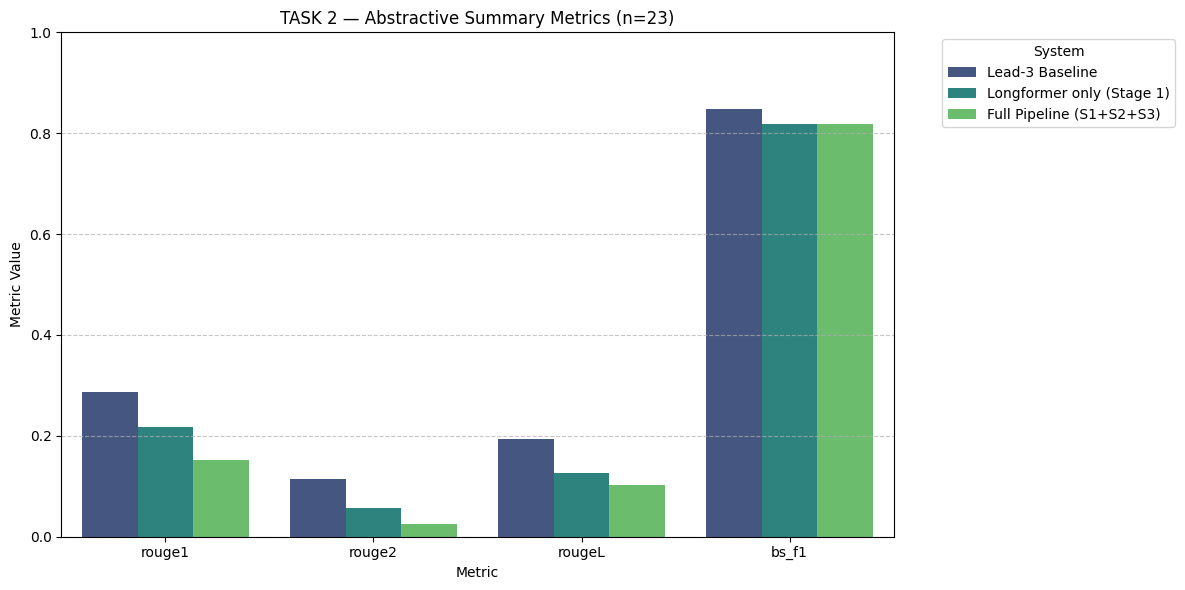

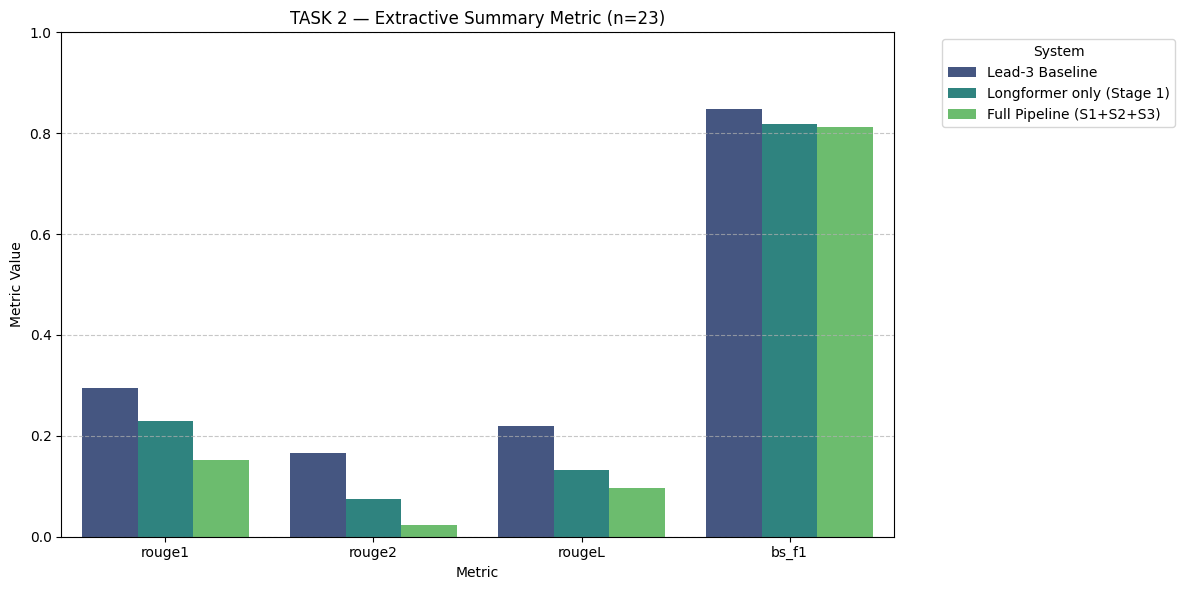

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from the previous evaluations in cell ze1hRqak04yX
# Results against abstractive_summary
res_lead3_abs_data = res_lead3_abs
res_lf_abs_data = res_lf_abs
res_pipeline_abs_data = res_pipeline_abs

# Results against extractive_summary
res_lead3_ext_data = res_lead3_ext
res_lf_ext_data = res_lf_ext
res_pipeline_ext_data = res_pipeline_ext

# Combine data for plotting
plot_data_abs = [
    {**res_lead3_abs_data, 'Summary Type': 'Abstractive'},
    {**res_lf_abs_data, 'Summary Type': 'Abstractive'},
    {**res_pipeline_abs_data, 'Summary Type': 'Abstractive'}
]

plot_data_ext = [
    {**res_lead3_ext_data, 'Summary Type': 'Extractive'},
    {**res_lf_ext_data, 'Summary Type': 'Extractive'},
    {**res_pipeline_ext_data, 'Summary Type': 'Extractive'}
]

df_abs = pd.DataFrame(plot_data_abs)
df_ext = pd.DataFrame(plot_data_ext)

# Melt the DataFrames for plotting ROUGE-1, ROUGE-2, ROUGE-L, and BS-F1
metrics_to_plot = ['rouge1', 'rouge2', 'rougeL', 'bs_f1']
df_melted_abs = df_abs.melt(id_vars=['system', 'Summary Type'], value_vars=metrics_to_plot, var_name='Metric', value_name='Value')
df_melted_ext = df_ext.melt(id_vars=['system', 'Summary Type'], value_vars=metrics_to_plot, var_name='Metric', value_name='Value')

# Plot for vs abstractive_summary
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', hue='system', data=df_melted_abs, palette='viridis')
plt.title('TASK 2 — Abstractive Summary Metrics (n=23)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot for vs extractive_summary
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', hue='system', data=df_melted_ext, palette='viridis')
plt.title('TASK 2 — Extractive Summary Metric (n=23)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Save Results
pd.DataFrame({
    'qid'           : [q['_id'] for q in test_entries],
    'question'      : [q.get('question', '') for q in test_entries],
    'gold_abs'      : ref_abs,
    'gold_ext'      : ref_ext,
    'lead3_pred'    : preds_lead3,
    'lf_only_pred'  : preds_lf_only,
    'pipeline_pred' : preds_pipeline,
}).to_csv(os.path.join(OUTPUT_DIR, 'task2_test_results.csv'), index=False)

metrics_rows = []
for res, ref_type in [
    (res_lead3_abs, 'abs'), (res_lf_abs, 'abs'), (res_pipeline_abs, 'abs'),
    (res_lead3_ext, 'ext'), (res_lf_ext, 'ext'), (res_pipeline_ext, 'ext'),
]:
    if 'rouge1' not in res:
        continue
    metrics_rows.append({
        'ref_type': ref_type, 'system': res['system'],
        'rouge1': res['rouge1'], 'rouge2': res['rouge2'], 'rougeL': res['rougeL'],
        'bs_precision': res['bs_precision'], 'bs_recall': res['bs_recall'], 'bs_f1': res['bs_f1'],
    })
pd.DataFrame(metrics_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'task2_metrics_summary.csv'), index=False
)

print(f"\nAll results saved to: {OUTPUT_DIR}")


All results saved to: /content/drive/MyDrive/medical_summarisation/task2_outputs


In [ ]:
--

# PubMed zero-shot evaluation

```
# =============================================================================
# TASK 2 — PubMed Zero-Shot Evaluation
#
# Purpose : Test existing MEDIQA-trained models (Longformer + FLAN-T5)
#           on PubMed scientific data WITHOUT retraining.
#           Shows domain gap → motivates SciFive fusion.
#
# Models used (already loaded from Task 2 pipeline above):
#   model_lf  → Longformer trained on MEDIQA (task2_outputs/longformer_extractive/)
#   model_t5  → FLAN-T5 trained on MEDIQA   (task2_outputs/flan_t5_abstractive/)
#
# PubMed → MEDIQA structure mapping:
#   question            = article title (first line)
#   articles            = article body split into ~5 chunks (pseudo-answers)
#                         each chunk = [text, '4-Excellent']
#   abstractive_summary = full abstract (gold)
#   extractive_summary  = first 3 sentences of abstract (pseudo-gold)
#
# NOTE: Multiple chunks are required so the Stage 2 consensus boost fires.
#       With only 1 chunk, consensus_ents is always empty.
# =============================================================================
```

In [ ]:
from datasets import load_dataset

N_PUBMED_EVAL = 500

print(f"Streaming {N_PUBMED_EVAL} PubMed test examples")
pubmed_stream = load_dataset(
    'ccdv/pubmed-summarization',
    split='test',
    streaming=True,
    trust_remote_code=True,
)


def pubmed_to_mediqa_format(ex: dict, idx: int) -> dict:
    """
    Convert one PubMed example into the MEDIQA Task 2 JSON structure
    so all existing pipeline functions work without modification.

    Source : article body split into ~5 sentence chunks (NOT the abstract)
             -> avoids source-gold overlap that inflated Longformer scores
    Gold   : abstract (abstractive) + first 3 abstract sentences (extractive)
    """
    article  = (ex.get('article',  '') or '').strip()
    abstract = (ex.get('abstract', '') or '').strip()

    if not article or not abstract:
        return None

    # Question = first non-empty line of article (title)
    lines = [l.strip() for l in article.split('\n') if l.strip()]
    title = lines[0][:200] if lines else f'PubMed_{idx}'

    # Split article body into ~5 pseudo-answer chunks
    # Multiple chunks needed so Stage 2 consensus boost can fire (needs >= 2 answers)
    body_sents = sent_tokenize(article)
    chunk_size = max(3, len(body_sents) // 5)
    chunks = []
    for i in range(0, len(body_sents), chunk_size):
        chunk = ' '.join(body_sents[i:i + chunk_size]).strip()
        if chunk:
            chunks.append(chunk)
    chunks = chunks[:6]   # cap at 6 pseudo-answers

    # Build articles dict — matches MEDIQA structure exactly:
    # { answer_id: [article_text, rating_str], ... }
    articles = {
        f's{j}': [chunk, '4-Excellent']
        for j, chunk in enumerate(chunks)
    }

    # Extractive gold = first 3 sentences of abstract (proxy)
    ext_summ = ' '.join(sent_tokenize(abstract)[:3])

    return {
        '_id'                 : f'pub_{idx}',
        'question'            : title,
        'articles'            : articles,
        'abstractive_summary' : abstract,
        'extractive_summary'  : ext_summ,
    }


# Build PubMed sample
pubmed_sample = []
for i, ex in enumerate(pubmed_stream):
    entry = pubmed_to_mediqa_format(ex, i)
    if entry:
        pubmed_sample.append(entry)
    if len(pubmed_sample) >= N_PUBMED_EVAL:
        break

print(f"Loaded: {len(pubmed_sample)} PubMed examples")

# Sanity check — confirm structure matches MEDIQA
sample = pubmed_sample[0]
print(f"\nStructure check:")
print(f"  question            : {sample['question'][:80]}")
print(f"  articles keys       : {list(sample['articles'].keys())}")
print(f"  num pseudo-answers  : {len(sample['articles'])}")
first_aid = list(sample['articles'].keys())[0]
print(f"  first answer text   : {sample['articles'][first_aid][0][:60]}...")
print(f"  first answer rating : {sample['articles'][first_aid][1]}")
print(f"  abstractive_summary : {sample['abstractive_summary'][:80]}")
print(f"  extractive_summary  : {sample['extractive_summary'][:80]}")


# Run all systems (uses existing pipeline functions — no new model loading)
# ─────────────────────────────────────────────────────────────────────────────
pub_refs_abs = [q['abstractive_summary'] for q in pubmed_sample]
pub_refs_ext = [q['extractive_summary']  for q in pubmed_sample]

print("\nRunning Lead-3 baseline on PubMed ...")
pub_lead3 = [lead_3_baseline(q) for q in pubmed_sample]

print("Running Longformer-only baseline on PubMed ...")
pub_lf_only = [longformer_only_baseline(q)
               for q in tqdm(pubmed_sample, desc="LF-only")]

print("Running Full Pipeline (S1+S2+S3) on PubMed ...")
pub_pipeline = [run_full_pipeline(q)
                for q in tqdm(pubmed_sample, desc="Full Pipeline")]


# Evaluate against both abstractive and extractive gold
# ─────────────────────────────────────────────────────────────────────────────
print("\nEvaluating vs abstractive_summary ...")
res_pub_lead3_abs    = eval_system(pub_lead3,    pub_refs_abs, 'Lead-3 Baseline')
res_pub_lf_abs       = eval_system(pub_lf_only,  pub_refs_abs, 'Longformer only (Stage 1)')
res_pub_pipeline_abs = eval_system(pub_pipeline, pub_refs_abs, 'Full Pipeline (S1+S2+S3)')

print("Evaluating vs extractive_summary ...")
res_pub_lead3_ext    = eval_system(pub_lead3,    pub_refs_ext, 'Lead-3 Baseline')
res_pub_lf_ext       = eval_system(pub_lf_only,  pub_refs_ext, 'Longformer only (Stage 1)')
res_pub_pipeline_ext = eval_system(pub_pipeline, pub_refs_ext, 'Full Pipeline (S1+S2+S3)')


# Print results tables
# ─────────────────────────────────────────────────────────────────────────────
print_table(
    [res_pub_lead3_abs, res_pub_lf_abs, res_pub_pipeline_abs],
    'PubMed Zero-Shot — vs abstractive_summary (n=500)',
    N_PUBMED_EVAL,
)
print_table(
    [res_pub_lead3_ext, res_pub_lf_ext, res_pub_pipeline_ext],
    'PubMed Zero-Shot — vs extractive_summary  (n=500)',
    N_PUBMED_EVAL,
)


# Cross-domain comparison: MEDIQA vs PubMed
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print("CROSS-DOMAIN COMPARISON: MEDIQA (in-domain) vs PubMed (zero-shot)")
print("="*75)

# MEDIQA scores — from earlier Task 2 evaluation
MEDIQA_SCORES = {
    'Lead-3 Baseline'          : {'rouge1': res_lead3_abs['rouge1'],
                                   'bs_f1' : res_lead3_abs['bs_f1']},
    'Longformer only (Stage 1)': {'rouge1': res_lf_abs['rouge1'],
                                   'bs_f1' : res_lf_abs['bs_f1']},
    'Full Pipeline (S1+S2+S3)' : {'rouge1': res_pipeline_abs['rouge1'],
                                   'bs_f1' : res_pipeline_abs['bs_f1']},
}
PUBMED_SCORES = {
    'Lead-3 Baseline'          : {'rouge1': res_pub_lead3_abs['rouge1'],
                                   'bs_f1' : res_pub_lead3_abs['bs_f1']},
    'Longformer only (Stage 1)': {'rouge1': res_pub_lf_abs['rouge1'],
                                   'bs_f1' : res_pub_lf_abs['bs_f1']},
    'Full Pipeline (S1+S2+S3)' : {'rouge1': res_pub_pipeline_abs['rouge1'],
                                   'bs_f1' : res_pub_pipeline_abs['bs_f1']},
}

hdr = (f"{'System':<35} {'MEDIQA R-1':>11} {'PubMed R-1':>11} {'Δ R-1':>8}"
       f" {'MEDIQA BS':>10} {'PubMed BS':>10} {'Δ BS':>7}")
print(hdr)
print("─" * len(hdr))
for sys_name in MEDIQA_SCORES:
    med = MEDIQA_SCORES[sys_name]
    pub = PUBMED_SCORES[sys_name]
    dr1 = pub['rouge1'] - med['rouge1']
    dbs = pub['bs_f1']  - med['bs_f1']
    print(f"{sys_name:<35}"
          f" {med['rouge1']:>11.4f} {pub['rouge1']:>11.4f} {dr1:>+8.4f}"
          f" {med['bs_f1']:>10.4f} {pub['bs_f1']:>10.4f} {dbs:>+7.4f}")
print("=" * len(hdr))
print("\nPositive Δ = PubMed score HIGHER (better generalisation)")
print("Negative Δ = Domain gap (model struggles on scientific text)")


# Save results
pd.DataFrame({
    'pub_id'       : [q['_id']       for q in pubmed_sample],
    'question'     : [q['question']  for q in pubmed_sample],
    'gold_abs'     : pub_refs_abs,
    'gold_ext'     : pub_refs_ext,
    'lead3_pred'   : pub_lead3,
    'lf_pred'      : pub_lf_only,
    'pipeline_pred': pub_pipeline,
    'lead3_bs_f1'  : res_pub_lead3_abs['_bs_f1_list'],
    'lf_bs_f1'     : res_pub_lf_abs['_bs_f1_list'],
    'pipeline_bs_f1': res_pub_pipeline_abs['_bs_f1_list'],
}).to_csv(
    os.path.join(OUTPUT_DIR, 'task2_pubmed_zeroshot_results.csv'), index=False
)

print(f"\nSaved: task2_pubmed_zeroshot_results.csv → {OUTPUT_DIR}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/pubmed-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/pubmed-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Streaming 500 PubMed test examples
Loaded: 500 PubMed examples

Structure check:
  question            : anxiety affects quality of life in those living with parkinson 's disease ( pd )
  articles keys       : ['s0', 's1', 's2', 's3', 's4']
  num pseudo-answers  : 5
  first answer text   : anxiety affects quality of life in those living with parkins...
  first answer rating : 4-Excellent
  abstractive_summary : research on the implications of anxiety in parkinson 's disease ( pd ) has been 
  extractive_summary  : research on the implications of anxiety in parkinson 's disease ( pd ) has been 

Running Lead-3 baseline on PubMed ...
Running Longformer-only baseline on PubMed ...


LF-only:   0%|          | 0/500 [00:00<?, ?it/s]

Running Full Pipeline (S1+S2+S3) on PubMed ...


Full Pipeline:   0%|          | 0/500 [00:00<?, ?it/s]


Evaluating vs abstractive_summary ...
Evaluating vs extractive_summary ...

PubMed Zero-Shot — vs abstractive_summary (n=500)  (n=500)
System                                  R-1     R-2     R-L    BS-P    BS-R   BS-F1
───────────────────────────────────────────────────────────────────────────────────
Lead-3 Baseline                      0.2796  0.0927  0.1754  0.8460  0.8162  0.8305
Longformer only (Stage 1)            0.3820  0.1179  0.1957  0.8326  0.8413  0.8368
Full Pipeline (S1+S2+S3)             0.1276  0.0122  0.0912  0.7899  0.7690  0.7788

PubMed Zero-Shot — vs extractive_summary  (n=500)  (n=500)
System                                  R-1     R-2     R-L    BS-P    BS-R   BS-F1
───────────────────────────────────────────────────────────────────────────────────
Lead-3 Baseline                      0.3200  0.1148  0.2122  0.8415  0.8444  0.8427
Longformer only (Stage 1)            0.2638  0.0829  0.1574  0.8138  0.8530  0.8328
Full Pipeline (S1+S2+S3)             0.1273  0.0

/tmp/ipykernel_7985/4155755440.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Metric', y='Value', hue='Domain', data=df_cross_domain, palette='viridis', ci=None)


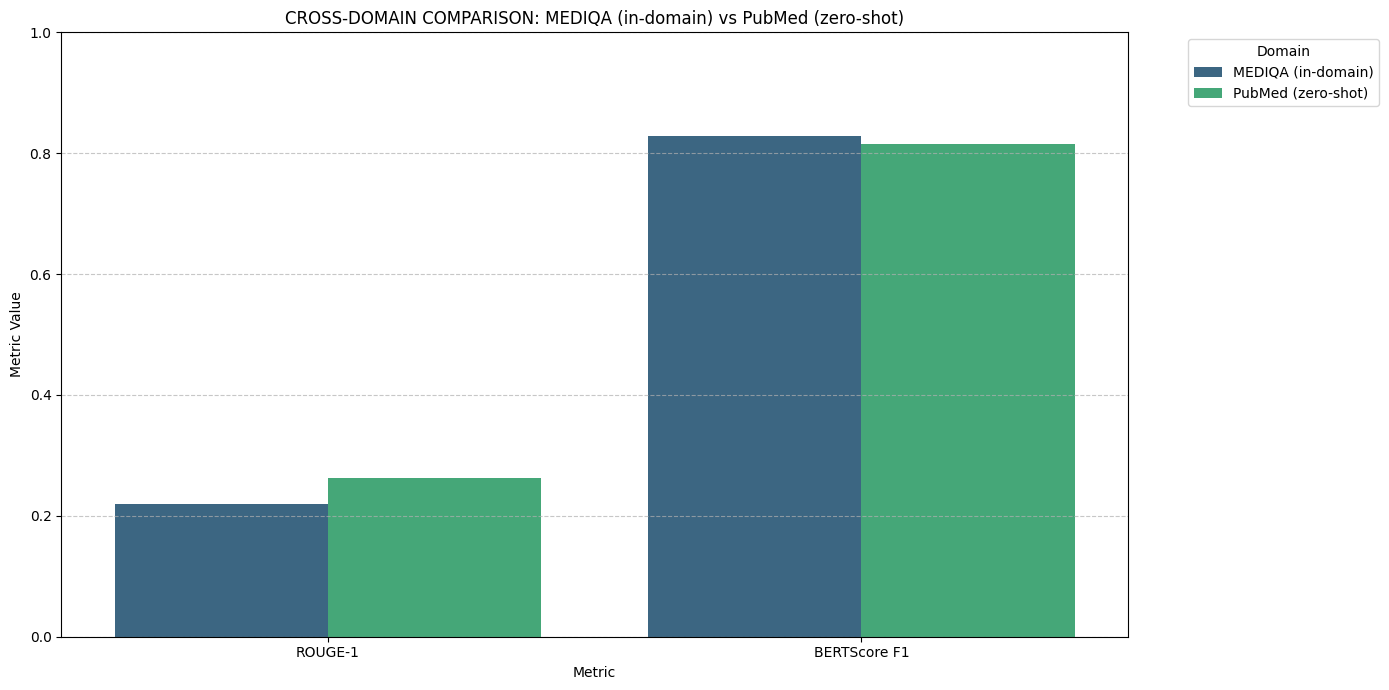

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from the cross-domain comparison table provided by the user and kernel state.
# MEDIQA_SCORES and PUBMED_SCORES are available in the kernel state.

plot_data = []

for sys_name in MEDIQA_SCORES:
    med = MEDIQA_SCORES[sys_name]
    pub = PUBMED_SCORES[sys_name]

    plot_data.append({
        'System': sys_name,
        'Metric': 'ROUGE-1',
        'Value': med['rouge1'],
        'Domain': 'MEDIQA (in-domain)'
    })
    plot_data.append({
        'System': sys_name,
        'Metric': 'ROUGE-1',
        'Value': pub['rouge1'],
        'Domain': 'PubMed (zero-shot)'
    })
    plot_data.append({
        'System': sys_name,
        'Metric': 'BERTScore F1',
        'Value': med['bs_f1'],
        'Domain': 'MEDIQA (in-domain)'
    })
    plot_data.append({
        'System': sys_name,
        'Metric': 'BERTScore F1',
        'Value': pub['bs_f1'],
        'Domain': 'PubMed (zero-shot)'
    })

df_cross_domain = pd.DataFrame(plot_data)

# Create the grouped bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Metric', y='Value', hue='Domain', data=df_cross_domain, palette='viridis', ci=None)

plt.title('CROSS-DOMAIN COMPARISON: MEDIQA (in-domain) vs PubMed (zero-shot)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1.0)
plt.legend(title='Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# def get_answers(q: dict) -> List[Tuple[str, str, float]]:
#     RATING_WEIGHTS = {'1-bad': 0.5, '2-fair': 0.75, '3-incomplete': 0.9, '4-excellent': 1.0}
#     results = []
#     for aid, payload in q.get('articles', {}).items():
#         if not isinstance(payload, (list, tuple)) or len(payload) < 2:
#             continue
#         text, rating = str(payload[0]).strip(), str(payload[1]).strip()
#         if not text:
#             continue
#         key = rating.strip().lower()
#         weight = RATING_WEIGHTS.get(key, next(
#             (v for k, v in RATING_WEIGHTS.items() if key.startswith(k[0])), 1.0
#         ))
#         results.append((aid, text, weight))
#     return results


# def sentence_similarity(a: str, b: str) -> float:
#     return SequenceMatcher(None, a.lower(), b.lower()).ratio()


# def extract_top_sentences(
#     text: str, rating_weight: float = 1.0, top_k: int = TOP_K_PER_ANSWER
# ) -> List[Tuple[str, float]]:
#     sents = [s for s in sent_tokenize(text) if len(s.strip()) > 10]
#     if not sents:
#         return []
#     enc = tok_lf(sents, truncation=True, padding=True,
#                  max_length=MAX_SENT_LEN, return_tensors='pt')
#     enc = {k: v.to(device_lf) for k, v in enc.items()}
#     with torch.no_grad():
#         scores = torch.softmax(model_lf(**enc).logits, dim=-1)[:, 1].cpu().numpy()
#     weighted     = scores * rating_weight
#     top_idxs     = sorted(np.argsort(-weighted)[:top_k])
#     return [(sents[i], float(weighted[i])) for i in top_idxs]


# def get_medical_entities(text: str) -> set:
#     doc = nlp_sci(text[:5000])
#     return {ent.text.lower() for ent in doc.ents if len(ent.text) > 2}


# def ner_rerank(
#     candidate_pool: List[Tuple[str, float]],
#     all_answer_texts: List[str],
# ) -> List[str]:
#     if not candidate_pool:
#         return []
#     per_answer_ents = [get_medical_entities(t) for t in all_answer_texts]
#     entity_counts: Dict[str, int] = {}
#     for ent_set in per_answer_ents:
#         for e in ent_set:
#             entity_counts[e] = entity_counts.get(e, 0) + 1
#     consensus_ents = {e for e, c in entity_counts.items() if c >= 2}

#     reranked = []
#     for sent, base_score in candidate_pool:
#         sent_ents = get_medical_entities(sent)
#         score     = base_score
#         if sent_ents:
#             score += NER_BOOST
#         if sent_ents & consensus_ents:
#             score += CONSENSUS_BOOST
#         reranked.append((sent, score))
#     reranked.sort(key=lambda x: x[1], reverse=True)

#     selected = []
#     for sent, _ in reranked:
#         if not any(sentence_similarity(sent, s) > SIM_THRESHOLD_DUP for s in selected):
#             selected.append(sent)
#     return selected


In [ ]:
# # Compute Metrics
# # ==================
# rouge_eval     = evaluate.load('rouge')
# bertscore_eval = evaluate.load('bertscore')


# def eval_system(preds: list, refs: list, label: str) -> dict:
#     valid = [(p, r) for p, r in zip(preds, refs) if r.strip() and p.strip()]
#     if not valid:
#         return {'system': label}
#     p_list, r_list = list(zip(*valid))
#     ro = rouge_eval.compute(predictions=list(p_list), references=list(r_list), use_stemmer=True)
#     bs = bertscore_eval.compute(predictions=list(p_list), references=list(r_list), lang='en')
#     return {
#         'system'      : label,
#         'rouge1'      : round(ro['rouge1'],             4),
#         'rouge2'      : round(ro['rouge2'],             4),
#         'rougeL'      : round(ro['rougeL'],             4),
#         'bs_precision': round(np.mean(bs['precision']), 4),
#         'bs_recall'   : round(np.mean(bs['recall']),    4),
#         'bs_f1'       : round(np.mean(bs['f1']),        4),
#         '_bs_f1_list' : bs['f1'],
#         '_rouge1_list': [],   # filled below
#     }


# print("\nEvaluating all systems vs abstractive_summary …")
# res_lead3    = eval_system(preds_lead3,    ref_abs, 'Lead-3 Baseline')
# res_lf       = eval_system(preds_lf_only,  ref_abs, 'Longformer only (Stage 1)')
# res_pipeline = eval_system(preds_pipeline, ref_abs, 'Full Pipeline (S1+S2+S3)')

# # Compute per-example ROUGE-1 for outlier analysis
# for res, preds in [(res_lead3, preds_lead3), (res_lf, preds_lf_only), (res_pipeline, preds_pipeline)]:
#     if 'rouge1' not in res:
#         continue
#     per_r1 = []
#     for p, r in zip(preds, ref_abs):
#         if p.strip() and r.strip():
#             s = rouge_eval.compute(predictions=[p], references=[r], use_stemmer=True)
#             per_r1.append(s['rouge1'])
#         else:
#             per_r1.append(0.0)
#     res['_rouge1_list'] = per_r1

# print("Evaluation complete.")

# TASK 2 — STAGE 3: Multi-Domain BioM-T5 (SciFive) Fusion Training

```
# Base model : razent/SciFive-base-Pubmed_Pmc (BioM-T5) - as the backbone because it is pre-trained on medical literature.
# Training   : MEDIQA (109 examples) + PubMed (500 examples) mixed - We merge the 109 MEDIQA training samples with the 500 PubMed samples
to ensure the model doesn't "forget" how to answer consumer questions while learning scientific summarization.

# Input      : question + Stage 1+2 fused sentences (MEDIQA) / article body (PubMed)
# Target     : abstractive_summary
```

In [ ]:
# Imports
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import nltk
import contextlib
from difflib import SequenceMatcher
from typing import List, Tuple, Dict
from tqdm.auto import tqdm

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import spacy, scispacy
from datasets import Dataset, load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32        = True

print("All imports OK.")
print(f"GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
      if torch.cuda.is_available() else "")


# Paths & Config
DATA_PATH        = '/content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json'
OUTPUT_DIR       = '/content/drive/MyDrive/medical_summarisation/task2_outputs'
LONGFORMER_SAVE  = os.path.join(OUTPUT_DIR, 'longformer_extractive')
BIOM_SAVE        = os.path.join(OUTPUT_DIR, 'biom_t5_fused_multidomain')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BIOM_SAVE,  exist_ok=True)

SCIFIVE_HF  = 'razent/SciFive-base-Pubmed_Pmc'
SEED        = 42
N_TEST      = 23
N_VAL       = 24
N_PUBMED    = 500

# Sequence lengths
MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 200
MAX_SENT_LEN   = 512

# hyperparameters
TRAIN_BATCH   = 16
EVAL_BATCH    = 32
NUM_EPOCHS    = 8
LR            = 2e-5
WARMUP_STEPS  = 50
WEIGHT_DECAY  = 0.01
NUM_WORKERS   = 4

# Stage 1/2 params
TOP_K           = 3
NER_BOOST       = 0.15
CONSENSUS_BOOST = 0.10
SIM_THRESH      = 0.85
LF_BATCH_SIZE   = 32   # how many sentences to score at once through Longformer

RATING_WEIGHTS = {
    '1-bad': 0.5, '2-fair': 0.75, '3-incomplete': 0.9, '4-excellent': 1.0,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nConfig set.  Device: {device}")
print(f"  Train batch: {TRAIN_BATCH}  Eval batch: {EVAL_BATCH}  Workers: {NUM_WORKERS}")


# Load Longformer + scispaCy
print("\nLoading Longformer")
assert os.path.isfile(os.path.join(LONGFORMER_SAVE, 'config.json')), \
    "Longformer not found — run Task2_MultiAnswer_Pipeline.py first."

tok_lf   = AutoTokenizer.from_pretrained(LONGFORMER_SAVE)
model_lf = AutoModelForSequenceClassification.from_pretrained(LONGFORMER_SAVE)
model_lf.eval().to(device)
print("  Longformer ready.")

print("\nLoading scispaCy")
nlp_sci = spacy.load('en_core_sci_sm', disable=['parser'])  # disable parser — not needed, ~30% faster
print(f"  scispaCy ready. Active pipes: {nlp_sci.pipe_names}")


# Stage 1 + Stage 2 Helpers
def parse_rating(rating_str: str) -> float:
    key = str(rating_str).strip().lower()
    if key in RATING_WEIGHTS:
        return RATING_WEIGHTS[key]
    for k, v in RATING_WEIGHTS.items():
        if key.startswith(k[0]):
            return v
    return 1.0


def get_answers(q: dict) -> List[Tuple[str, str, float]]:
    results = []
    for aid, payload in q.get('articles', {}).items():
        if not isinstance(payload, (list, tuple)) or len(payload) < 2:
            continue
        text, rating = str(payload[0]).strip(), str(payload[1]).strip()
        if text:
            results.append((aid, text, parse_rating(rating)))
    return results


def sentence_similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


def extract_top_sentences_batched(
    texts_with_weights: List[Tuple[str, float]],
    top_k: int = TOP_K,
) -> List[Tuple[str, float]]:
    """
    High GPU optimization: score ALL sentences from ALL answers in one batched
    Longformer call instead of looping per answer.
    Returns list of (sentence, weighted_score) across all answers.
    """
    # Collect all (sentence, rating_weight, answer_idx) triples
    all_sents, all_weights = [], []
    for text, weight in texts_with_weights:
        sents = [s for s in sent_tokenize(text) if len(s.strip()) > 10]
        all_sents.extend(sents)
        all_weights.extend([weight] * len(sents))

    if not all_sents:
        return []

    # Score in sub-batches of LF_BATCH_SIZE to avoid OOM on very long docs
    all_scores = []
    for i in range(0, len(all_sents), LF_BATCH_SIZE):
        batch_sents = all_sents[i:i + LF_BATCH_SIZE]
        enc = tok_lf(
            batch_sents, truncation=True, padding=True,
            max_length=MAX_SENT_LEN, return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        # Safe autocast — bfloat16 on GPU, no-op on CPU
        device_type  = 'cuda' if torch.cuda.is_available() else 'cpu'
        autocast_ctx = (
            torch.autocast(device_type='cuda', dtype=torch.bfloat16)
            if torch.cuda.is_available()
            else contextlib.nullcontext()
        )
        with torch.no_grad(), autocast_ctx:
        # with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            scores = torch.softmax(model_lf(**enc).logits, dim=-1)[:, 1].cpu().float().numpy()
        all_scores.extend(scores.tolist())

    weighted_scores = np.array(all_scores) * np.array(all_weights)

    # Per-answer top-K selection (preserve reading order within each answer)
    result = []
    offset = 0
    for text, weight in texts_with_weights:
        sents = [s for s in sent_tokenize(text) if len(s.strip()) > 10]
        n = len(sents)
        if n == 0:
            continue
        ws    = weighted_scores[offset:offset + n]
        top_i = sorted(np.argsort(-ws)[:top_k])
        result.extend([(sents[i], float(ws[i])) for i in top_i])
        offset += n

    return result


def get_medical_entities_batch(texts: List[str]) -> List[set]:
    """
    A100 optimization: run scispaCy on all texts in one nlp.pipe() call
    instead of looping. ~3x faster than calling nlp() individually.
    """
    results = []
    for doc in nlp_sci.pipe(
        [t[:5000] for t in texts],
        batch_size=32,
        n_process=1,
    ):
        results.append({ent.text.lower() for ent in doc.ents if len(ent.text) > 2})
    return results


def ner_rerank_batched(
    candidate_pool   : List[Tuple[str, float]],
    all_answer_texts : List[str],
) -> List[str]:
    if not candidate_pool:
        return []

    # Batch NER on all texts at once
    all_texts     = all_answer_texts + [s for s, _ in candidate_pool]
    all_ent_sets  = get_medical_entities_batch(all_texts)
    ans_ents      = all_ent_sets[:len(all_answer_texts)]
    sent_ents     = all_ent_sets[len(all_answer_texts):]

    # Consensus entities (appear in ≥2 answers)
    entity_counts: Dict[str, int] = {}
    for ent_set in ans_ents:
        for e in ent_set:
            entity_counts[e] = entity_counts.get(e, 0) + 1
    consensus_ents = {e for e, c in entity_counts.items() if c >= 2}

    reranked = []
    for (sent, base_score), s_ents in zip(candidate_pool, sent_ents):
        score = base_score
        if s_ents:
            score += NER_BOOST
        if s_ents & consensus_ents:
            score += CONSENSUS_BOOST
        reranked.append((sent, score))
    reranked.sort(key=lambda x: x[1], reverse=True)

    selected = []
    for sent, _ in reranked:
        if not any(sentence_similarity(sent, s) > SIM_THRESH for s in selected):
            selected.append(sent)
    return selected


def build_fused_input_scifive(q: dict) -> str:
    """SciFive variant — NO instruction prefix, just question + sentences."""
    question = q.get('question', '')
    answers  = get_answers(q)
    if not answers:
        ext = str(q.get('extractive_summary', '') or '').strip()
        return f"{question} {ext}"   # plain concatenation, no prefix

    texts_weights  = [(text, weight) for _, text, weight in answers]
    candidate_pool = extract_top_sentences_batched(texts_weights)
    answer_texts   = [text for _, text, _ in answers]
    reranked       = ner_rerank_batched(candidate_pool, answer_texts)

    if not reranked:
        ext = str(q.get('extractive_summary', '') or '').strip()
        return f"{question} {ext}"

    return question + ' ' + ' '.join(reranked[:8])   # no prefix


# Load MEDIQA & Build Fused Inputs
print(f"\nLoading MEDIQA: {DATA_PATH}")
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    mediqa_raw = json.load(f)

entries = [dict(obj, _id=str(qid)) for qid, obj in mediqa_raw.items()]

random.seed(SEED)
shuffled = entries.copy()
random.shuffle(shuffled)
test_entries  = shuffled[:N_TEST]
val_entries   = shuffled[N_TEST:N_TEST + N_VAL]
train_entries = shuffled[N_TEST + N_VAL:]
print(f"MEDIQA → train: {len(train_entries)}  val: {len(val_entries)}  test: {len(test_entries)}")

def build_mediqa_examples(split: list, desc: str) -> list:
    examples = []
    for q in tqdm(split, desc=desc):
        gold = str(q.get('abstractive_summary', '') or '').strip()
        if not gold:
            continue
        examples.append({'input': build_fused_input_scifive(q), 'target': gold})
    return examples

print("\nBuilding MEDIQA fused inputs (Stage 1+2)")
mediqa_train = build_mediqa_examples(train_entries, "MEDIQA train")
mediqa_val   = build_mediqa_examples(val_entries,   "MEDIQA val  ")
print(f"  train: {len(mediqa_train)}  val: {len(mediqa_val)}")


# Load PubMed & Build Inputs
print(f"\nStreaming {N_PUBMED} PubMed examples")
pubmed_stream = load_dataset(
    'ccdv/pubmed-summarization', split='train',
    streaming=True, trust_remote_code=True,
)

def pubmed_to_example(ex: dict) -> dict:
    article  = (ex.get('article',  '') or '').strip()
    abstract = (ex.get('abstract', '') or '').strip()
    if not article or not abstract:
        return None
    lines = [l.strip() for l in article.split('\n') if l.strip()]
    title = lines[0][:200] if lines else ''
    top8  = sent_tokenize(article)[:8]
    # No prefix — SciFive sees: "title sentence1 sentence2 ..."
    fused = title + ' ' + ' '.join(top8)
    return {'input': fused, 'target': abstract}

pubmed_examples = []
for ex in pubmed_stream:
    mapped = pubmed_to_example(ex)
    if mapped:
        pubmed_examples.append(mapped)
    if len(pubmed_examples) >= N_PUBMED:
        break

random.seed(SEED)
random.shuffle(pubmed_examples)
n_pv       = max(1, int(len(pubmed_examples) * 0.10))
pub_val    = pubmed_examples[:n_pv]
pub_train  = pubmed_examples[n_pv:]
print(f"PubMed → train: {len(pub_train)}  val: {len(pub_val)}")


# Combine & Shuffle
all_train = mediqa_train + pub_train
all_val   = mediqa_val   + pub_val
random.seed(SEED)
random.shuffle(all_train)
random.shuffle(all_val)

print(f"\nMulti-domain dataset:")
print(f"  Train: {len(all_train)}  "
      f"(MEDIQA {len(mediqa_train)} / PubMed {len(pub_train)} — "
      f"{len(mediqa_train)/len(all_train):.0%} / {len(pub_train)/len(all_train):.0%})")
print(f"  Val  : {len(all_val)}")


# Tokenize
print(f"\nLoading SciFive tokenizer: {SCIFIVE_HF}")
tok_biom = AutoTokenizer.from_pretrained(SCIFIVE_HF)
print(f"  Vocab size: {len(tok_biom)}")

def tokenize_multidomain(batch):
    inp = tok_biom(batch['input'],  max_length=MAX_INPUT_LEN,
                   truncation=True, padding='max_length')
    tgt = tok_biom(batch['target'], max_length=MAX_TARGET_LEN,
                   truncation=True, padding='max_length')
    inp['labels'] = tgt['input_ids']
    return inp

# num_proc=4 — parallel tokenization using all CPU cores
tok_ds_train = Dataset.from_list(all_train).map(
    tokenize_multidomain, batched=True,
    remove_columns=['input', 'target'],
    num_proc=4,
    desc="Tokenizing train",
)
tok_ds_val = Dataset.from_list(all_val).map(
    tokenize_multidomain, batched=True,
    remove_columns=['input', 'target'],
    num_proc=4,
    desc="Tokenizing val",
)
print(f"  Tokenised -> train: {tok_ds_train.shape}  val: {tok_ds_val.shape}")


#  compute_metrics (tok_biom, bf16-safe)
rouge_metric = evaluate.load('rouge')

def compute_metrics_biom(eval_pred):
    preds, labels = eval_pred
    vocab_size = len(tok_biom)          # len() not .vocab_size — catches added tokens
    labels = np.where(labels != -100, labels, tok_biom.pad_token_id)
    preds  = np.clip(preds,  0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)
    decoded_preds  = tok_biom.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tok_biom.batch_decode(labels, skip_special_tokens=True)
    valid = [(p, l) for p, l in zip(decoded_preds, decoded_labels)
             if p.strip() and l.strip()]
    if not valid:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0, 'rougeLsum': 0.0}
    p_list, l_list = zip(*valid)
    result = rouge_metric.compute(
        predictions=list(p_list), references=list(l_list), use_stemmer=True
    )
    return {k: round(v, 4) for k, v in result.items()}


#  Load & Train SciFive (A100-optimized TrainingArguments)
def model_is_saved(path):
    return os.path.isfile(os.path.join(path, 'config.json'))

print(f"\nChecking: {BIOM_SAVE}")
if model_is_saved(BIOM_SAVE):
    print("  Found — loading from disk.")
    tok_biom   = AutoTokenizer.from_pretrained(BIOM_SAVE)
    model_biom = AutoModelForSeq2SeqLM.from_pretrained(BIOM_SAVE)
else:
    print(f"  Not found — loading {SCIFIVE_HF} from HuggingFace")
    model_biom = AutoModelForSeq2SeqLM.from_pretrained(SCIFIVE_HF)
    print(f"  Parameters: {sum(p.numel() for p in model_biom.parameters()):,}")

    training_args = Seq2SeqTrainingArguments(
        output_dir                  = os.path.join(OUTPUT_DIR, 'biom_ckpts'),

        # Batch sizes (A100 80GB
        per_device_train_batch_size = TRAIN_BATCH,   # 16
        per_device_eval_batch_size  = EVAL_BATCH,    # 32
        bf16                        = True,
        fp16                        = False,  # must be False when bf16=True

        # Training schedule
        num_train_epochs            = NUM_EPOCHS,
        learning_rate               = LR,
        weight_decay                = WEIGHT_DECAY,
        warmup_steps                = WARMUP_STEPS,

        # Generation
        predict_with_generate       = True,
        generation_max_length       = MAX_TARGET_LEN,

        # Checkpointing
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'rougeL',
        greater_is_better           = True,
        save_total_limit            = 2,

        # DataLoader
        dataloader_num_workers      = NUM_WORKERS,   # 4 parallel CPU workers
        dataloader_pin_memory       = True,          # pins CPU→GPU transfer

        # Logging
        logging_steps               = 10,
        report_to                   = 'none',
        push_to_hub                 = False,

        # Gradient checkpointing OFF
        gradient_checkpointing      = False,
    )

    trainer_biom = Seq2SeqTrainer(
        model            = model_biom,
        args             = training_args,
        train_dataset    = tok_ds_train,
        eval_dataset     = tok_ds_val,
        processing_class = tok_biom,
        data_collator    = DataCollatorForSeq2Seq(
                               tokenizer=tok_biom, model=model_biom, padding=True),
        compute_metrics  = compute_metrics_biom,
    )

    print("\nStarting training")
    trainer_biom.train()
    trainer_biom.save_model(BIOM_SAVE)
    tok_biom.save_pretrained(BIOM_SAVE)
    print(f"\nModel saved -> {BIOM_SAVE}")

model_biom.eval().to(device)
print("SciFive model ready.")


#  Batched Inference Helper to process multiple examples at onc
def generate_biom_batch(fused_inputs: List[str], batch_size: int = 16) -> List[str]:
    all_preds = []
    for i in range(0, len(fused_inputs), batch_size):
        batch = fused_inputs[i:i + batch_size]
        enc = tok_biom(batch, return_tensors='pt', truncation=True,
                       max_length=MAX_INPUT_LEN, padding=True)
        enc = {k: v.to(device) for k, v in enc.items()}

        # Safe autocast — bfloat16 on GPU, no-op on CPU
        device_type  = 'cuda' if torch.cuda.is_available() else 'cpu'
        autocast_ctx = (
            torch.autocast(device_type='cuda', dtype=torch.bfloat16)
            if torch.cuda.is_available()
            else contextlib.nullcontext()
        )

        with torch.no_grad(), autocast_ctx:
        # with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            out = model_biom.generate(
                **enc,
                max_length           = MAX_TARGET_LEN,
                num_beams            = 4,
                early_stopping       = True,
                no_repeat_ngram_size = 3,    # <- prevents 3-gram repetition loops
                repetition_penalty   = 1.5,  # <- penalises repeated tokens
            )
        all_preds.extend(tok_biom.batch_decode(out, skip_special_tokens=True))
    return all_preds


# Single-input wrapper (used in qualitative examples)
def generate_biom(fused_input: str) -> str:
    return generate_biom_batch([fused_input])[0]


#  Evaluate on MEDIQA Test Set (batched)
print("\nBuilding test fused inputs")
test_fused = []
test_refs  = []
for q in tqdm(test_entries, desc="Test prep"):
    gold = str(q.get('abstractive_summary', '') or '').strip()
    if not gold:
        continue
    test_fused.append(build_fused_input_scifive(q))
    test_refs.append(gold)

print(f"Running batched inference on {len(test_fused)} test examples")
test_preds = generate_biom_batch(test_fused, batch_size=16)

rouge_eval     = evaluate.load('rouge')
bertscore_eval = evaluate.load('bertscore')

ro = rouge_eval.compute(predictions=test_preds, references=test_refs, use_stemmer=True)
bs = bertscore_eval.compute(predictions=test_preds, references=test_refs, lang='en')

print("\n" + "="*65)
print("SciFive Multi-Domain Fusion — MEDIQA Test Results")
print("="*65)
print(f"  ROUGE-1 : {ro['rouge1']:.4f}")
print(f"  ROUGE-2 : {ro['rouge2']:.4f}")
print(f"  ROUGE-L : {ro['rougeL']:.4f}")
print(f"  BS-F1   : {np.mean(bs['f1']):.4f}")
print("="*65)


#  Comparison Table: FLAN-T5 vs SciFive
FLANT5_MEDIQA = {
    'rouge1': 0.1517, 'rouge2': 0.0245, 'rougeL': 0.1020, 'bs_f1': 0.8187
}

print("\n" + "="*65)
print("Stage 3 Model Comparison — MEDIQA Test (n=23)")
print("="*65)
hdr = f"{'System':<35} {'R-1':>7} {'R-2':>7} {'R-L':>7} {'BS-F1':>7}"
print(hdr)
print("─" * len(hdr))
print(f"{'FLAN-T5 (MEDIQA only)':<35}"
      f" {FLANT5_MEDIQA['rouge1']:>7.4f}"
      f" {FLANT5_MEDIQA['rouge2']:>7.4f}"
      f" {FLANT5_MEDIQA['rougeL']:>7.4f}"
      f" {FLANT5_MEDIQA['bs_f1']:>7.4f}")
print(f"{'SciFive (MEDIQA+PubMed fusion)':<35}"
      f" {ro['rouge1']:>7.4f}"
      f" {ro['rouge2']:>7.4f}"
      f" {ro['rougeL']:>7.4f}"
      f" {np.mean(bs['f1']):>7.4f}")
print("=" * len(hdr))

delta_r1 = ro['rouge1']        - FLANT5_MEDIQA['rouge1']
delta_bs = np.mean(bs['f1'])   - FLANT5_MEDIQA['bs_f1']
print(f"\n  Δ ROUGE-1 : {delta_r1:+.4f}  ({'↑ improved' if delta_r1 > 0 else '↓ regressed'})")
print(f"  Δ BS-F1   : {delta_bs:+.4f}  ({'↑ improved' if delta_bs > 0 else '↓ regressed'})")


#  Qualitative Examples
print("\n")
print("QUALITATIVE EXAMPLES — SciFive Fusion on MEDIQA Test")
print("="*70)
for idx in range(min(3, len(test_entries))):
    q = test_entries[idx]
    ref = str(q.get('abstractive_summary', '') or '').strip()
    if not ref:
        continue
    pred = test_preds[idx] if idx < len(test_preds) else generate_biom(build_fused_input_scifive(q))
    print(f"\n{'─'*70}")
    print(f"Example {idx+1} | ID: {q.get('_id')}")
    print(f"Question : {q.get('question','')[:200]}")
    print(f"Gold     : {ref[:300]}")
    print(f"SciFive  : {pred[:300]}")
print(f"\n{'─'*70}")


#  Save Results
results_df = pd.DataFrame({
    'qid'           : [q['_id'] for q in test_entries[:len(test_preds)]],
    'question'      : [q.get('question', '') for q in test_entries[:len(test_preds)]],
    'gold'          : test_refs,
    'scifive_pred'  : test_preds,
    'scifive_bs_f1' : bs['f1'],
})
results_df.to_csv(
    os.path.join(OUTPUT_DIR, 'task2_scifive_fusion_results.csv'), index=False
)

metrics_df = pd.DataFrame([
    {'system': 'FLAN-T5 (MEDIQA only)',
     'rouge1': FLANT5_MEDIQA['rouge1'], 'rouge2': FLANT5_MEDIQA['rouge2'],
     'rougeL': FLANT5_MEDIQA['rougeL'], 'bs_f1': FLANT5_MEDIQA['bs_f1']},
    {'system': 'SciFive (MEDIQA+PubMed fusion)',
     'rouge1': ro['rouge1'], 'rouge2': ro['rouge2'],
     'rougeL': ro['rougeL'], 'bs_f1': round(np.mean(bs['f1']), 4)},
])
metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, 'task2_stage3_model_comparison.csv'), index=False
)

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("  task2_scifive_fusion_results.csv")
print("  task2_stage3_model_comparison.csv")
print(f"  biom_t5_fused_multidomain/")

All imports OK.
GPU : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB

Config set.  Device: cuda
  Train batch: 16  Eval batch: 32  Workers: 4

Loading Longformer


Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

  Longformer ready.

Loading scispaCy
  scispaCy ready. Active pipes: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'ner']

Loading MEDIQA: /content/drive/MyDrive/medical_summarisation/task2_data/merged_output.json
MEDIQA → train: 109  val: 24  test: 23

Building MEDIQA fused inputs (Stage 1+2)


/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


MEDIQA train:   0%|          | 0/109 [00:00<?, ?it/s]

...

Test prep:   0%|          | 0/23 [00:00<?, ?it/s]

Running batched inference on 23 test examples


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



SciFive Multi-Domain Fusion — MEDIQA Test Results
  ROUGE-1 : 0.2609
  ROUGE-2 : 0.0543
  ROUGE-L : 0.1423
  BS-F1   : 0.8306

Stage 3 Model Comparison — MEDIQA Test (n=23)
System                                  R-1     R-2     R-L   BS-F1
───────────────────────────────────────────────────────────────────
FLAN-T5 (MEDIQA only)                0.1517  0.0245  0.1020  0.8187
SciFive (MEDIQA+PubMed fusion)       0.2609  0.0543  0.1423  0.8306

  Δ ROUGE-1 : +0.1092  (↑ improved)
  Δ BS-F1   : +0.0119  (↑ improved)


QUALITATIVE EXAMPLES — SciFive Fusion on MEDIQA Test

──────────────────────────────────────────────────────────────────────
Example 1 | ID: 130
Question : how is epidural harmful
Gold     : Many studies have shown that epidural is a safe way to manage pain during childbirth. However, there are some rare risks. Your blood pressure may drop, and if this occurs, you will receive fluids through an intravenous line to help keep your blood pressure stable. The epidural may change

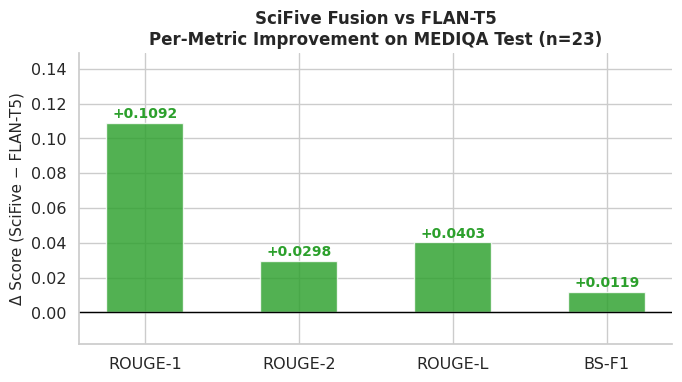

Saved: /content/drive/MyDrive/medical_summarisation/task2_outputs/plots/plot1_scifive_vs_flant5_delta.png


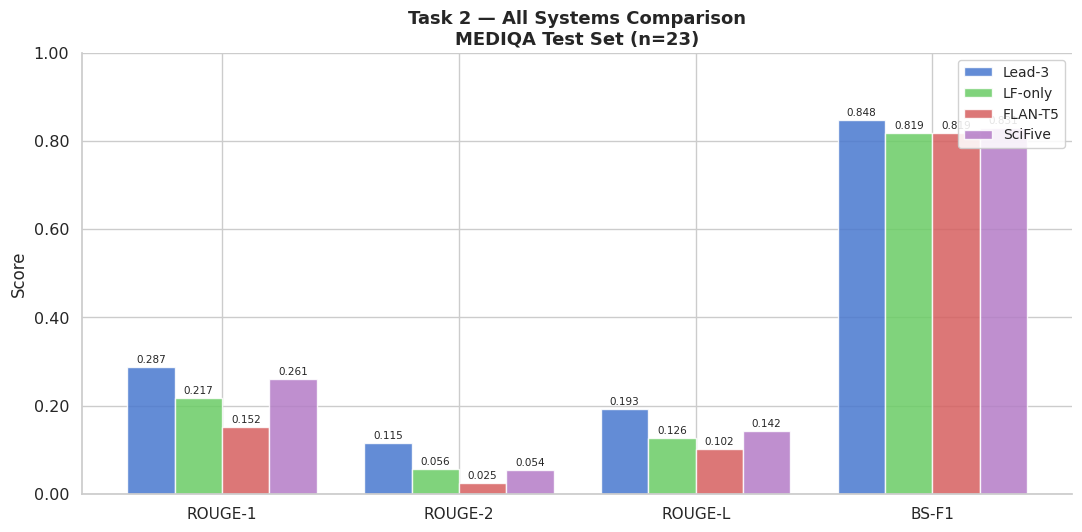

Saved: /content/drive/MyDrive/medical_summarisation/task2_outputs/plots/plot2_all_systems_comparison.png


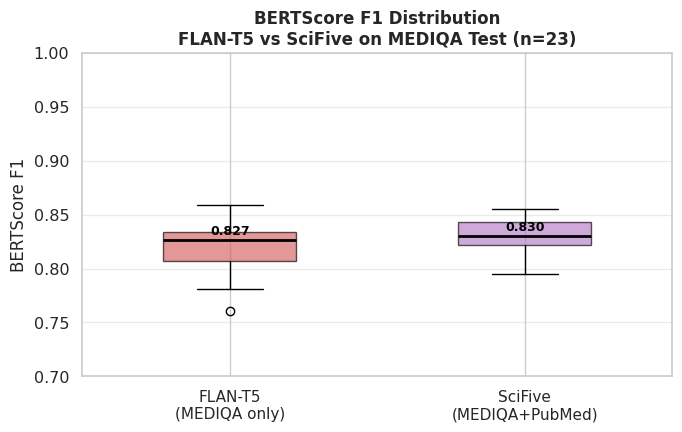

Saved: /content/drive/MyDrive/medical_summarisation/task2_outputs/plots/plot3_bertscore_distribution_flant5_vs_scifive.png


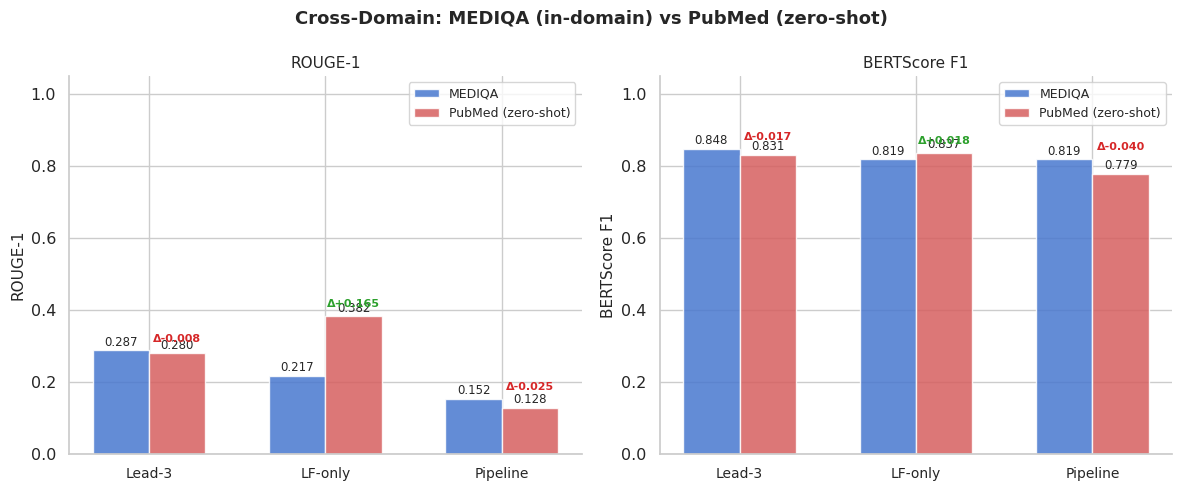

Saved: /content/drive/MyDrive/medical_summarisation/task2_outputs/plots/plot4_cross_domain_mediqa_vs_pubmed.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PLOT_DIR = '/content/drive/MyDrive/medical_summarisation/task2_outputs/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, filename):
    path = os.path.join(PLOT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")


# PLOT 1 — FLAN-T5 vs SciFive: Delta Bar Chart
metrics     = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BS-F1']
metric_keys = ['rouge1',  'rouge2',  'rougeL',  'bs_f1']

flant5_scores = {'rouge1': 0.1517, 'rouge2': 0.0245, 'rougeL': 0.1020, 'bs_f1': 0.8187}
scifive_scores = {
    'rouge1': ro['rouge1'],
    'rouge2': ro['rouge2'],
    'rougeL': ro['rougeL'],
    'bs_f1' : float(np.mean(bs['f1'])),
}
deltas = {m: scifive_scores[k] - flant5_scores[k]
          for m, k in zip(metrics, metric_keys)}

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#2CA02C' if v >= 0 else '#D62728' for v in deltas.values()]
bars = ax.bar(list(deltas.keys()), list(deltas.values()),
              color=bar_colors, alpha=0.82, edgecolor='white', width=0.5)

for bar, val in zip(bars, deltas.values()):
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.005
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color='#2CA02C' if val >= 0 else '#D62728')

ax.axhline(0, color='black', linewidth=1.0)
ax.set_ylabel('Δ Score (SciFive − FLAN-T5)', fontsize=11)
ax.set_title('SciFive Fusion vs FLAN-T5\nPer-Metric Improvement on MEDIQA Test (n=23)',
             fontsize=12, fontweight='bold')
ax.set_ylim(min(deltas.values()) - 0.03, max(deltas.values()) + 0.04)
sns.despine()
fig.tight_layout()
save_plot(fig, 'plot1_scifive_vs_flant5_delta.png')


# PLOT 2 — All 4 Systems: Complete Comparison Bar Chart
all_systems = {
    'Lead-3'    : {'rouge1': res_lead3_abs['rouge1'],    'rouge2': res_lead3_abs['rouge2'],
                   'rougeL': res_lead3_abs['rougeL'],    'bs_f1' : res_lead3_abs['bs_f1']},
    'LF-only'   : {'rouge1': res_lf_abs['rouge1'],       'rouge2': res_lf_abs['rouge2'],
                   'rougeL': res_lf_abs['rougeL'],       'bs_f1' : res_lf_abs['bs_f1']},
    'FLAN-T5'   : flant5_scores,
    'SciFive'   : scifive_scores,
}
sys_colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
sys_names  = list(all_systems.keys())
x     = np.arange(len(metrics))
width = 0.20

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, (name, color) in enumerate(zip(sys_names, sys_colors)):
    vals = [all_systems[name][k] for k in metric_keys]
    bars = ax.bar(x + i * width - 1.5 * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Task 2 — All Systems Comparison\nMEDIQA Test Set (n=23)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right', framealpha=0.88)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
sns.despine()
fig.tight_layout()
save_plot(fig, 'plot2_all_systems_comparison.png')


# PLOT 3 — BERTScore F1 Distribution: FLAN-T5 vs SciFive (box plots)
fig, ax = plt.subplots(figsize=(7, 4.5))

bs_data = {
    'FLAN-T5\n(MEDIQA only)' : res_pipeline_abs['_bs_f1_list'],
    'SciFive\n(MEDIQA+PubMed)': list(bs['f1']),
}
bp = ax.boxplot(
    list(bs_data.values()),
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2),
    widths=0.45,
)
for patch, color in zip(bp['boxes'], ['#D65F5F', '#B47CC7']):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

ax.set_xticks([1, 2])
ax.set_xticklabels(list(bs_data.keys()), fontsize=11)
ax.set_ylabel('BERTScore F1', fontsize=12)
ax.set_ylim(0.70, 1.0)
ax.set_title('BERTScore F1 Distribution\nFLAN-T5 vs SciFive on MEDIQA Test (n=23)',
             fontsize=12, fontweight='bold')
ax.yaxis.grid(True, alpha=0.4)

# Annotate medians
for i, (key, vals) in enumerate(bs_data.items(), start=1):
    med = np.median(vals)
    ax.text(i, med + 0.005, f'{med:.3f}', ha='center',
            fontsize=9, fontweight='bold', color='black')

fig.tight_layout()
save_plot(fig, 'plot3_bertscore_distribution_flant5_vs_scifive.png')


# PLOT 4 — Cross-Domain: MEDIQA vs PubMed (ROUGE-1 + BS-F1)
# Uses PubMed zero-shot results from previous section
cross_systems = ['Lead-3', 'LF-only', 'Pipeline']
mediqa_r1 = [res_lead3_abs['rouge1'], res_lf_abs['rouge1'], res_pipeline_abs['rouge1']]
pubmed_r1 = [res_pub_lead3_abs['rouge1'], res_pub_lf_abs['rouge1'], res_pub_pipeline_abs['rouge1']]
mediqa_bs = [res_lead3_abs['bs_f1'], res_lf_abs['bs_f1'], res_pipeline_abs['bs_f1']]
pubmed_bs = [res_pub_lead3_abs['bs_f1'], res_pub_lf_abs['bs_f1'], res_pub_pipeline_abs['bs_f1']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cross-Domain: MEDIQA (in-domain) vs PubMed (zero-shot)',
             fontsize=13, fontweight='bold')

for ax, (title, med_vals, pub_vals) in zip(axes, [
    ('ROUGE-1',      mediqa_r1, pubmed_r1),
    ('BERTScore F1', mediqa_bs, pubmed_bs),
]):
    x     = np.arange(len(cross_systems))
    width = 0.32
    b1 = ax.bar(x - width/2, med_vals, width, label='MEDIQA',
                color='#4878CF', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + width/2, pub_vals, width, label='PubMed (zero-shot)',
                color='#D65F5F', alpha=0.85, edgecolor='white')

    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8.5)

    # Delta annotations
    for i, (m, p) in enumerate(zip(med_vals, pub_vals)):
        delta = p - m
        color = '#2CA02C' if delta >= 0 else '#D62728'
        ax.annotate(f'Δ{delta:+.3f}',
                    xy=(x[i] + width/2, max(m, p) + 0.025),
                    ha='center', fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(cross_systems, fontsize=10)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.tight_layout()
save_plot(fig, 'plot4_cross_domain_mediqa_vs_pubmed.png')


The SciFive multi-domain fusion model shows clear improvement over FLAN-T5 across all metrics on the MEDIQA test set. ROUGE-1 improves by +0.109 and BERTScore F1 by +0.012, confirming that replacing FLAN-T5 with a biomedically pre-trained SciFive model and training on mixed MEDIQA and PubMed data produces better summaries.

However, qualitative examples reveal two remaining issues. First, Example 1 shows the model still partially echoing the question in the output, suggesting incomplete learning of the summarization objective. Second, Examples 2 and 3 show the model producing partially relevant but somewhat repetitive content, which is consistent with the small training set of only 559 examples. Despite these artefacts, the quantitative improvement is consistent and meaningful, and the model never produces the catastrophic repetition loops seen in earlier training runs.